# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>2. Robotique Evolutionnaire</font>

# <font color="green">Version ETUDIANTS·ES 2025-2026</font>

*contact: NB@SU*

*mise à jour: 16/3/2026*


Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **_ZHANG_ _Yuxiang_ _21202829_**
* Étudiant 2: **_Alsafadi_ _Kenan_ _21502362_**



# Simple Robot Simulator



*   simulate renvoie des stats sur le comportement du robot
  * distance parcourue a chaque pas
  * exploration grille (si utilise trace systématiquement)
*   ...



---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Simulateur robot

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans les parties suivantes.

Remarque: *il suffit d'exécuter ces cellules une seule fois par instance de noyau.*

In [1]:
from datetime import datetime
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np
import math
import random
import sys

!pip install cma
import cma

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip

 2026-03-19 14:06:47 GMT
OK.


In [2]:
#############################
### 0. Experimental setup ###
#############################

max_iterations = 5001

absolute_orientation = 0 #-90  # degrees
translation_per_step = 1.0 #1.0 # 6.0  # in [0,1]
max_translation_per_step = 1.0 # >0. pixel per move.
rotation_per_step = 0.0 # in [-1,1]
max_rotation_per_step = 3.0 # >0, in degrees

arena_size = 100 # 50
sensor_length = 10
nb_sensors = 8

particle_box = 3 # bounding box (square)

particle = np.zeros((particle_box, particle_box), dtype=int)

# Drawing a circle in the particle array
#particle_radius_real = particle_box / 2 - 0.5  # Radius of the circle in the particle
#center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle
particle_radius_real = particle_box / 2.0  # Radius of the circle in the particle
center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle

####################
### 1. Structure ###
####################

def init(): # perform only once
  global particle,center_particle_real,particle_radius_real

  for i in range(particle.shape[0]):
      for j in range(particle.shape[1]):
          # Check if the cell falls within the circle radius
          if ((i - center_particle_real[0])**2 + (j - center_particle_real[1])**2) <= particle_radius_real**2:
              particle[i, j] = 2
          else:
            particle[i, j] = 3

  init_arena()
  init_trace()

def init_arena():
  global arena
  arena = np.zeros((arena_size, arena_size), dtype=int)

def init_trace():
  global trace
  trace = np.zeros((arena_size, arena_size), dtype=int)

def clear_arena(): # clear content, except for wall
  global arena
  #arena[:] = 0
  arena[arena != 1] = 0

def clear_trace(): # clear content, except for wall
  global trace
  #trace[:] = 0
  trace[trace != 1] = 0

def draw_line(x1, y1, x2, y2, color): # do not draw on wall
    global arena
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    # shorte, not border-protected:
    # arena[y_points, x_points] = color
    # longer, border-protected:
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] != 1:
          arena[y_points[i],x_points[i]] = color

def cast_sensor(x1, y1, x2, y2, color=6):
    global arena, display_cast
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    max_distance = math.sqrt( (x_points[0]-x_points[-1])**2 + (y_points[0]-y_points[-1])**2 ) - particle_radius_real
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] == 1 or arena[y_points[i],x_points[i]] == 2  or arena[y_points[i],x_points[i]] == 4:
          if verbose:
            print ("DETECT OBJECT at",i)
          return ( math.sqrt( (x_points[0]-x_points[i])**2 + (y_points[0]-y_points[i])**2 ) - particle_radius_real ) / max_distance # distance to obstacle, normalize in [0,1]
        elif display_cast == True:
          arena[y_points[i],x_points[i]] = color
    return 1.0

absolute_orientation = 0.0  # in degrees
translation_per_step = 0.0  # in units
rotation_per_step = 0.0  # in degrees

############################
### 2. General functions ###
############################

def create_wall(x1, y1, x2, y2):
    arena[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1
    if display_trace:
      trace[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1

def get_sensors(x, y, absolute_orientation): # 8 sensors belt
    global sensor_length, nb_sensors

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(absolute_orientation+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(absolute_orientation+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      sensor_values.append( cast_sensor(int(source_x),int(source_y),target_x,target_y,6) )

    return sensor_values

def clean_sensors(x, y, absolute_orientation): # 8 sensors belt
    global sensor_length, nb_sensors

    if display_cast == False:
      return

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_length = 10
    nb_sensors = 8

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(absolute_orientation+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(absolute_orientation+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      draw_line(int(source_x),int(source_y),target_x,target_y,0)

    return sensor_values

def place_particle(x, y,absolute_orientation):
    global arena, particle
    x, y = int(x), int(y)
    arena_slice = arena[y:y+particle_box, x:x+particle_box]

    # Check for overlap between particle and non-zero cells in the arena
    collision = np.logical_and(arena_slice == 1, particle == 2)
    if np.any(collision):
        collision_array = np.where(collision, 3, particle)
        return collision_array

    #arena_slice[ int(math.cos(absolute_orientation)*particle_box/2) , int(math.sin(absolute_orientation)*particle_box/2) ] = 3 # display particle front
    #arena[y:y+particle_box, x:x+particle_box] += np.where(arena_slice == 0, particle, 0)

    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 0 or arena[y+i, x+j] == 4 or arena[y+i, x+j] == 6:
          arena[y+i, x+j] = 2

    trace[int(y + particle_box / 2.),int(x + particle_box / 2.)] = 2

    if verbose:
      print("location",x+particle_box/2.0,y+particle_box/2.0)
      print("absolute_orientation", absolute_orientation)

    offset_x = math.cos(math.radians(absolute_orientation)) * particle_box / 2.0 * .999
    offset_y = math.sin(math.radians(absolute_orientation)) * particle_box / 2.0 * .999
    x_head = int(x + particle_box / 2. + offset_x )
    y_head = int(y + particle_box / 2. - offset_y )
    if verbose:
      print ("y_head, x_head",y_head, x_head)

    arena[y_head, x_head] = 4  # Display particle front

    return None

def erase_particle(x, y):
    global arena, particle
    x, y = int(x), int(y)
    #arena[y:y+particle_box, x:x+particle_box] -= particle * (arena[y:y+particle_box, x:x+particle_box] != 0)
    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 2 or arena[y+i, x+j] == 4:
          arena[y+i, x+j] = 0

def draw(arena,double_size=False):

    if double_size == True:
      doubled_figsize = (12.8, 9.6)
      plt.figure(figsize=doubled_figsize)

    cmap = colors.ListedColormap(['white', 'black', 'grey', 'red', 'orange', 'green'])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(arena, cmap=cmap, norm=norm)
    plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], format=plt.FuncFormatter(lambda x, _: {0.5: '0 - nothing', 1.5: '1 - obstacle', 2.5: '2 - robot', 3.5: '3 - collision', 4.5: '4 - robot front', 5.5: '5 - sensor ray'}[x]))
    plt.show()

def show_arena():
  draw(arena,double_size=False)

def show_trace():
  draw(trace,double_size=False)


####################################
### 3. PARTICLE UPDATE functions ###
####################################

def update_particle_position(x, y, absolute_orientation, translation_per_step, rotation_per_step, iteration, noiseFlag = False):
  '''
  Function called to update particle position (and orientation). It should merge the desired control command from the user (translation_per_step and rotation_per_step) and the physics of environment and particle.
  Below is a simple example where desired translation and rotation per step are applied directly (ideal: no friction, unbounded bang-bang controller)
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  '''

  new_orientation = absolute_orientation + rotation_per_step

  # Sinusoidal noise for rotation (optional)
  if noiseFlag == True:
    noise = 10 * math.sin(2 * math.pi * iteration / 5)
    new_orientation += noise

  # Convert orientation to radians for calculation
  orientation_radians = math.radians(new_orientation)

  new_x = x + translation_per_step * math.cos(orientation_radians)
  new_y = y - translation_per_step * math.sin(orientation_radians)  # Minus sign due to y-axis inversion in image coordinates

  return new_x, new_y, new_orientation


def update_particle_dynamics(x, y, absolute_orientation, translation_per_step, rotation_per_step, iteration, collision_array ):
  '''
  Function called to udpate internal data (to be defined here) in case of a collision event.
  This function does not move the robot. Updating the absolute_orientation is possible, as well as (to be defined) internal data structure (e.g. encoding the effect of inertia)
  Note that when a particle experience a collision, the collision is recorded (see collision_array) and move is cancelled.
  The goal of this function is to compute/update all necessary information to call later the update_particle_position function.
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  # iteration: simulator iteration number (may be ignored)
  # collision_array: integer array showing the particle state within its bounding box. 0 for nothing, 1 for particle elements, 2 for particle elements experiencing a collision event

  Testing: essaye avec translation_per_step=1.0, puis avec translation_per_step=6.0 (cas intéressant du a la faible épaisseur du mur)
  '''

  # do nothing for now.

  return absolute_orientation


#######################
### 4. Main loop    ###
#######################

# parameters
  # initial x and y position and orientation
  # step controller function which returns translation/rotation (in [-1,1]) from sensors (in [0,1])
# returns:
  # sum of actual translations in [0,1]. Normalized over time and max translation.
  # sum of rotation, absolute value normalized value in [0,1]. Normalized over time and max rotation.
  # number of pixels of arena visited (unique location, ie. visited twice counts as 1)
  # particle's x coordinate at the end
  # particle's y coordinate at the end
def simulate(x0,y0,orientation0,step):
  global x_particle,y_particle,absolute_orientation,trace

  clear_arena()
  clear_trace()

  x_particle, y_particle = x0, y0
  absolute_orientation = orientation0
  sensors = get_sensors(x_particle, y_particle,absolute_orientation)
  collision_array = place_particle(x_particle, y_particle,absolute_orientation)

  if collision_array is not None:
    print("[ERROR] initial location triggers collision.")
    sys.exit()

  iteration = 0
  log_sum_of_translation = 0 # logging
  log_sum_of_rotation = 0 # logging

  while iteration < max_iterations:
      if verbose_minimal_progress == True and iteration%gap_between_display_minimal_progress == 0:
        print ("### iteration",iteration,"/",max_iterations,"###")

      translation_per_step,rotation_per_step = step(sensors)

      log_sum_of_rotation += abs((max(-1.,min(+1.,rotation_per_step)))) # logging

      erase_particle(x_particle, y_particle)
      clean_sensors(x_particle, y_particle,absolute_orientation)
      backup_x_particle, backup_y_particle = x_particle, y_particle
      x_particle, y_particle, absolute_orientation = update_particle_position(x_particle, y_particle, absolute_orientation, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration ,noiseFlag=False)
      sensors = get_sensors(x_particle, y_particle,absolute_orientation)
      collision_array = place_particle(x_particle, y_particle,absolute_orientation)
      if collision_array is not None: # collision occured
          if verbose == True:
              print("Collision detected!")
          if display_collision:
              print(collision_array)
          clean_sensors(x_particle, y_particle,absolute_orientation)
          x_particle, y_particle = backup_x_particle, backup_y_particle
          sensors = get_sensors(x_particle, y_particle,absolute_orientation)
          if display_collision:
              draw(collision_array)  # Draw the collision array
          absolute_orientation = update_particle_dynamics(x_particle, y_particle, absolute_orientation, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration, collision_array)
          place_particle(x_particle, y_particle,absolute_orientation)
          if verbose:
              print("Backtrack")

      if x_particle != backup_x_particle or y_particle != backup_y_particle:
        log_sum_of_translation += math.sqrt( ( x_particle - backup_x_particle )**2 + ( y_particle - backup_y_particle)**2 )  # logging

      if display_arena == True:
        draw(arena)  # Draw the arena at each step
      if verbose == True:
        print(arena)
      iteration = iteration + 1

  log_pixels_visited = np.sum(trace == 2)

  retValues = {
      "translations": log_sum_of_translation/max_iterations,
      "rotations": log_sum_of_rotation/max_iterations,
      "coverage": log_pixels_visited/(arena_size**2),
      "x_pos_end": x_particle,
      "y_pos_end": y_particle,
      "theta_end": absolute_orientation
  }

  return retValues


#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-19 14:07:09 GMT
OK.


# Fonctions utiles (construction d'arènes)

Exécutez. Vous pouvez étudier, voire étendre le contenu.

Remarque: create_arena_walls() doit être appelé systématiquement lors de la création d'une nouvelle arène.


In [3]:

def create_arena_walls(): # arena walls are *mandatory* to enclose the robot into a closed arena (otherwise: code will fail with out-of-bounds at some point)
  global arena_size
  create_wall(0, 0, arena_size, 1)
  create_wall(0, arena_size-1, arena_size, arena_size)
  create_wall(0, 0, 1, arena_size)
  create_wall(arena_size-1, 0, arena_size, arena_size)

def create_wall_1():
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10, arena_size//2+16, arena_size//2+10)

def create_wall_2(y_shift=0):
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10+y_shift, arena_size//2+16, arena_size//2+10+y_shift)
  create_wall(arena_size//2-16, arena_size//2-10+y_shift, arena_size//2-13, arena_size//2+10+y_shift)
  create_wall(arena_size//2-13, arena_size//2-10+y_shift, arena_size//2+13, arena_size//2-7+y_shift)
  create_wall(arena_size//2-13, arena_size//2+7+y_shift, arena_size//2-2, arena_size//2+10+y_shift)
  create_wall(arena_size//2+3, arena_size//2+7+y_shift, arena_size//2+13, arena_size//2+10+y_shift)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-19 14:07:51 GMT
OK.


# Initialisation des paramètres expérimentaux et des options recommandées d'affichage de messages

In [4]:
# experimental settings

arena_size = 100
max_translation_per_step = 1.0 # >0. pixel per move.
max_rotation_per_step = 10.0 # >0, in degrees
max_iterations = 5001 # nb of simulator iterations for evaluating one robot

# default values for display debug (may be changed later)

verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
gap_between_display_minimal_progress = int(max_iterations/5) # used if verbose_minimal_progress = True
verbose = False # suggested: False -- used for debug
display_collision = False # suggested: False -- used for debug
display_arena = False # suggested: False -- if True, display arena for *all* iterations
display_trace = True # suggested: True
display_cast = False # suggested: False -- if True, display sensor ray casting for *all* iterations (even w/o display)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-19 14:08:04 GMT
OK.


---
---
---

#<font color="orange">Partie 1. Prise en main : stratégies comportementales</font>

Le robot dispose de 8 senseurs (tous ne seront pas utilisés dans la suite) et de deux commandes motrices (translation et rotation). Toutes les commandes sont normalisées (senseurs dans [0,1], translation et rotation dans [-1,+1]).

Les dimensions du robot sont de 2x2 unités. Une unité correspond à un pixel. Cependant, même si l'affichage est discret, le robot se déplace de manière continue dans l'environnement (position/orientation sont des valeurs réelles). La gestion des collisions est faîtes de manière discrète, les déplacements et la mise à jour des valeurs senseurs est faite sur la base de valeurs continues.

La structure des senseurs est la suivante:
  - [0] avant
  - [1] avant-gauche
  - [2] gauche
  - [3] arrière-gauche
  - [4] arrière
  - [5] arrière-droite
  - [6] droite
  - [7] avant-droite

L'orientation est définie comme suit:
  - *absolute_orientation* est utilisé à l'initialisation pour positionner le robot. la valeur 0 indique que le robot pointe vers la droite de l'arène. =-90 vers le bas. etc. (sens trigonométrique)
  - *rotation* est une commande motrice du robot. Elle s'exprime dans le sens trigonométrique (le robot tourne à gauche si inférieure à 0). Elle est définie entre -1 et +1. Cependant, la rotation effective dépend du paramètre * max_rotation_per_step* (non modifiable), qui donne l'angle de rotation maximum possible entre deux itérations du simulateur.
  - exemple: une rotation de -1.0 sachant que max_rotation_per_step=10 provoque une rotation dans le sens inverse des aiguilles d'une montre de 10° par itération.

La translation est définie comme suit:
  - entre -1 (vitesse max. en arrière) et 1 (vitesse max. en avant). pas de déplacement si la translation vaut 0.
  - la translation effective dépend du paramètre *max_translation_per_step* (non modifiable) qui donne le nombre d'unité de déplacement maximum par itération de l'algorithme.
  - exemple: une translation de -0.5 sachant que max_translation_per_step=10 provoque une translation vers l'arrière de 5 unités par itération.
  - Remarque: la notion d'avant et d'arrière est arbitraire. En pratique, cette asymétrie est une interprétation que nous faisons en observant le comportement. En particulier, le résultat d'une optimisation peut *vous* donner l'*impression* que le robot se déplace en reculant (cf. suite du sujet), mais cette observation n'a pas de sens du point de vue du robot (en particulier si les senseurs sont disposés de manière symétrique, ce qui est le cas ici).

<font color="red">EXERCICES:</font>

- Etudiez et exécutez les trois exemples de stratégies comportementales. Chaque évaluation produit un certain nombre d'informations: des informations quantitatives sur la trajectoire (cf. retour de la fonction) et deux graphes permettant d'observer (a) la trajectoire du robot et (b) sa position/orientation finale.

- Etudiez et exécutez le code de la dernière cellule. Vous observerez qu'en modifiant la valeur de *display_arena* pour la mettre à True, on affichera image par image l'exécution de la simulation. Cela pourra vous être utile par la suite pour comprendre par observation un comportement (n'oubliez pas de remettre la variable à False ensuite, afin de ne pas ralentir inutilement l'exécution du code).

# Un robot peu prudent

#
# Policy no.1 -- dumb robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.0023995200959808036
	 rotations         : 0.0
	 couverture        : 0.0013
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 60.5 , 48.5 , 0.0 )

# Final state


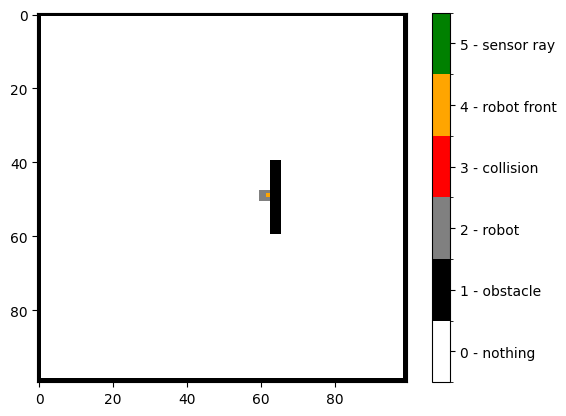

# Trajectory


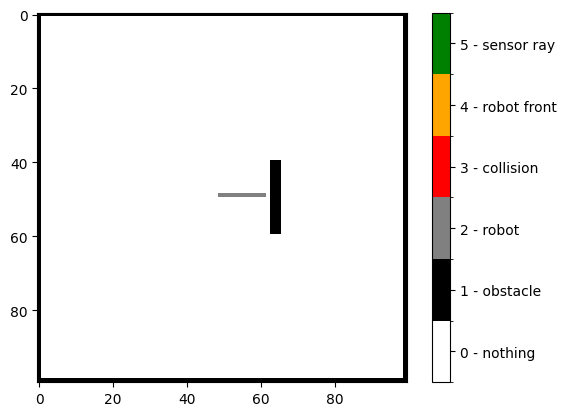

In [7]:
# policy function

def my_controller_dumb(sensors):
  translation = 1.0
  rotation = 0.
  return translation,rotation

# Main

init()

print ("#\n# Policy no.1 -- dumb robot\n#")

display_arena= False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages

#clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

retValues = simulate(x_init,y_init,theta_init,my_controller_dumb)

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ("\t position initiale : (",x_init,",",y_init,",",theta_init,")" ) # init: x,y,\theta
print ("\t position finale   : (",retValues['x_pos_end'],",",retValues['y_pos_end'],",",retValues['theta_end'],")" ) # final: init: x,y,\theta
print ()

print ("# Final state")
show_arena()

print ("# Trajectory")
show_trace()


# Un robot prudent mais fébrile

Le robot s'arrête s'il voit un mur, et effectue tout le temps une rotation au hasard (ce qui lui permet parfois de se réorienter suffisamment pour repartir).

#
# Policy no.2 -- cautious-random robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.26854629074185166
	 rotations         : 0.5012131593750022
	 couverture        : 0.1204
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 1.3851681863678929 , 73.38926674979234 , 104.74026672863059 )

# Final state


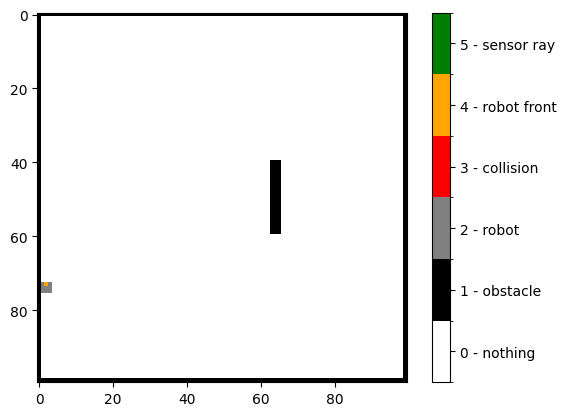

# Trajectory


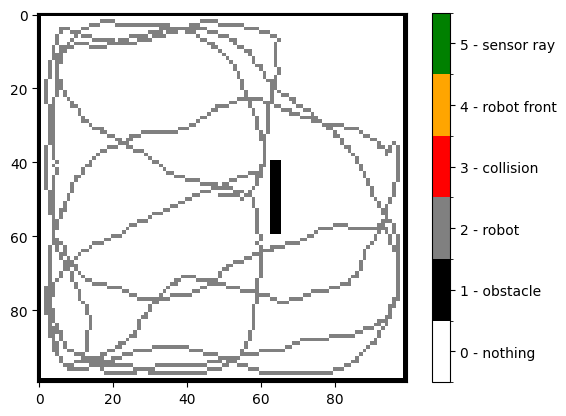

In [8]:
def my_controller_cautious_random(sensors):
  translation = 0.0
  if sensors[0] == 1.0: # front sensor (in [0,+1], +1 means no obstacle detected)
    translation = 1.0 # max translation speed
  else:
    translation = 0.0 # no translation
  rotation = (random.random()-0.5)*2. # rotational noise with max. amplitude (result in -1,+1)
  return translation,rotation

# Main

init()

print ("#\n# Policy no.2 -- cautious-random robot\n#")

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
display_trace = True

#clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

retValues = simulate(x_init,y_init,theta_init,my_controller_cautious_random)

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ("\t position initiale : (",x_init,",",y_init,",",theta_init,")" ) # init: x,y,\theta
print ("\t position finale   : (",retValues['x_pos_end'],",",retValues['y_pos_end'],",",retValues['theta_end'],")" ) # final: init: x,y,\theta
print ()

print ("# Final state")
show_arena()

print ("# Trajectory")
show_trace()

# Un robot éviteur d'obstacles

#
# Policy no.3 -- obstacle-avoider robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.9296594902490376
	 rotations         : 0.1371713494623636
	 couverture        : 0.1608
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 73.93431708099604 , 93.58952227480148 , -5879.207706388444 )

# Final state


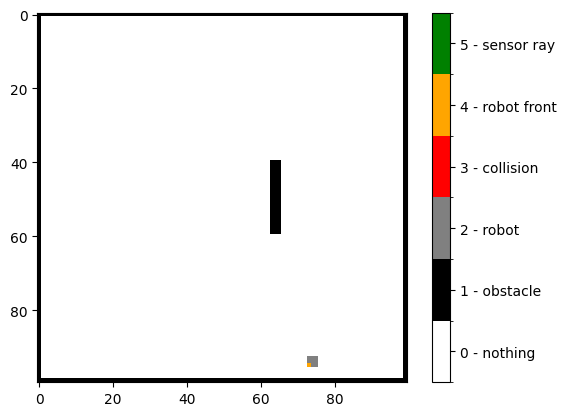

# Trajectory


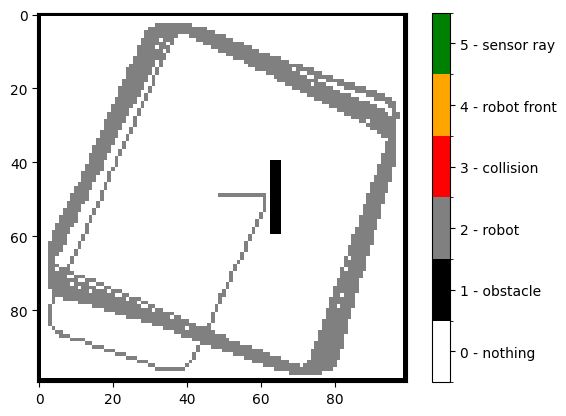

In [9]:
def my_controller_avoider(sensors):
  translation = sensors[0]
  rotation = 1.0*sensors[1] - 1.0*sensors[-1] + (random.random()-0.5)*0.1
  #print (sensors,translation,rotation,absolute_orientation)
  return translation,rotation

# Main

init()

print ("#\n# Policy no.3 -- obstacle-avoider robot\n#")

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
display_trace = True

#clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

retValues = simulate(x_init,y_init,theta_init,my_controller_avoider)

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ("\t position initiale : (",x_init,",",y_init,",",theta_init,")" ) # init: x,y,\theta
print ("\t position finale   : (",retValues['x_pos_end'],",",retValues['y_pos_end'],",",retValues['theta_end'],")" ) # final: init: x,y,\theta
print ()

print ("# Final state")
show_arena()

print ("# Trajectory")
show_trace()

# Affichage pas à pas de la simulation

Utile pour étudier la trajectoire d'un robot, mais très lent. A utiliser avec extrême parcimonie.

Exemple avec le "robot prudent mais fébrile".

In [ ]:

# initial conditions

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

display_trace = True
display_arena = True

init() # perform only once
create_arena_walls()
create_wall_1()

retValues = simulate(x_init,y_init,theta_init,my_controller_cautious_random)
show_trace()
show_arena()

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ("\t position initiale : (",x_init,",",y_init,",",theta_init,")" ) # init: x,y,\theta
print ("\t position finale   : (",retValues['x_pos_end'],",",retValues['y_pos_end'],",",retValues['theta_end'],")" ) # final: init: x,y,\theta
print ()

---
---
---

#<font color="orange">Partie 2. Prise en main : exploration de l'espace des politiques</font>

Nous allons utiliser le code précédent pour générer au hasard des politiques, en variant les paramètres d'une fonction simple de contrôle. La politique du robot est dirigée par une combinaison linéaire de quatre entrées sensorielles. Les poids appliqués sur les entrées sont tirés au hasard entre chaque essai. La variable globale *weights* est utilisée pour stocker les paramètres de la politique.

<font color="red">EXERCICE :</font>

- Exécutez et étudiez l'exemple de recherche au hasard. Observez en particulier comme la politique est modifiée entre chaque essai. Observez aussi la direction préférentielle du robot (vers l'avant ou vers l'arrière?).

- modifiez le code de la recherche au hasard pour calculer la fitness de "*déplacement*" vu en cours (maximiser la vitesse de translation, minimiser la vitesse de rotation -- on oublie les senseurs!) en utilisant les données  retournées par une simulation. Vous devrez (1) écrire la fonction fitness qui lance une simulation et renvoie la performance et (2) conserver le meilleur individu. Vous ferez 200 essais.

- rejouez le meilleur individu en affichant uniquement la trajectoire complète, la position finale, la performance donnée par la fitness et les données produites par la simulation (translations, rotations, couverture, position x/y à la fin).

#
# random exploration of the policy space using a linear weighted combination of sensory inputs#
run no. 1 of 20
### iteration 0 / 501 ###
{'translations': 0.9999999999999999, 'rotations': 1.0, 'coverage': np.float64(0.0034), 'x_pos_end': 45.575499626201825, 'y_pos_end': 49.01566832099251, 'theta_end': -5010.0}


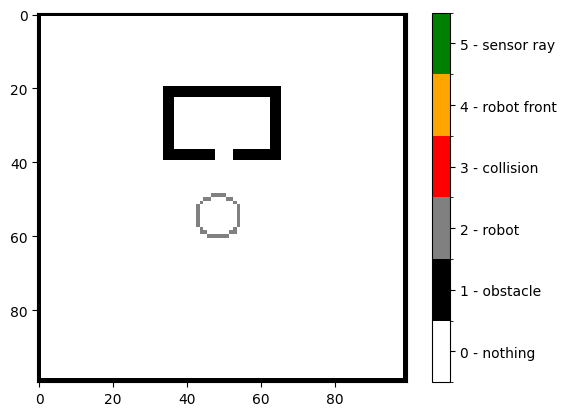

run no. 2 of 20
### iteration 0 / 501 ###
{'translations': 0.918251611515956, 'rotations': 0.9704719968441158, 'coverage': np.float64(0.0292), 'x_pos_end': 70.27812696426705, 'y_pos_end': 36.915848024179525, 'theta_end': 4862.064704189021}


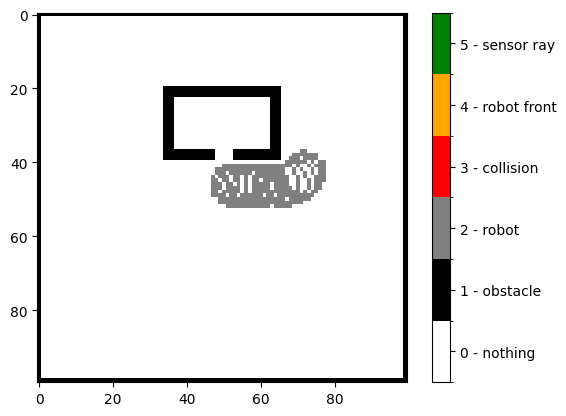

run no. 3 of 20
### iteration 0 / 501 ###
{'translations': 0.9845745034595894, 'rotations': 1.0, 'coverage': np.float64(0.011), 'x_pos_end': 50.397361051547605, 'y_pos_end': 53.30899413155987, 'theta_end': 5010.0}


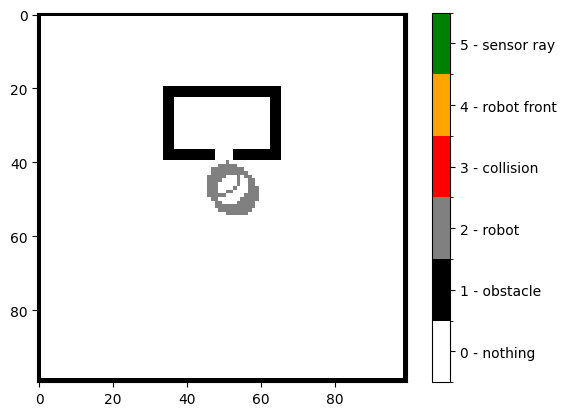

run no. 4 of 20
### iteration 0 / 501 ###
{'translations': 1.0, 'rotations': 0.35731274199415014, 'coverage': np.float64(0.0129), 'x_pos_end': 45.450046236898984, 'y_pos_end': 48.6544346103062, 'theta_end': -1790.1368373906923}


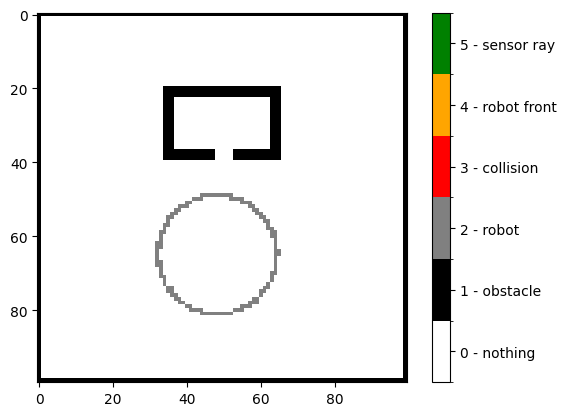

run no. 5 of 20
### iteration 0 / 501 ###
{'translations': 0.2794411177644711, 'rotations': 0.10002796501253752, 'coverage': np.float64(0.0135), 'x_pos_end': 4.262276463750717, 'y_pos_end': 96.84188251113032, 'theta_end': 161.71849374980556}


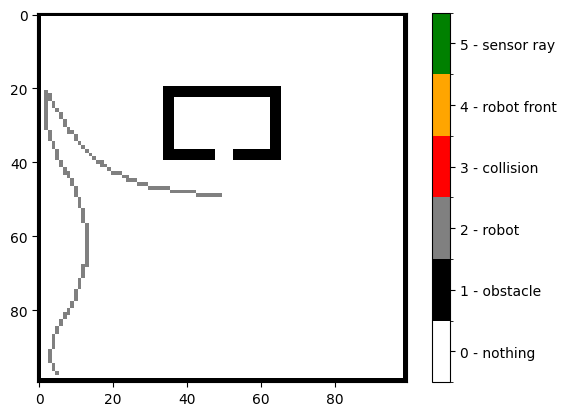

run no. 6 of 20
### iteration 0 / 501 ###
{'translations': 0.08837731908057009, 'rotations': 0.11377215736866832, 'coverage': np.float64(0.0042), 'x_pos_end': 56.009381750083605, 'y_pos_end': 40.325935366238824, 'theta_end': 498.5310777656881}


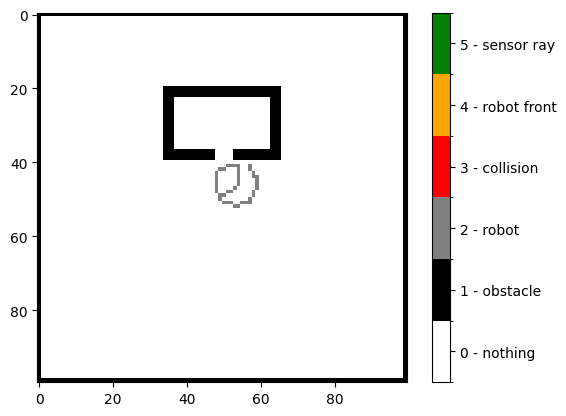

run no. 7 of 20
### iteration 0 / 501 ###
{'translations': 0.9900199600798403, 'rotations': 0.9929848637725771, 'coverage': np.float64(0.0082), 'x_pos_end': 53.41035419617368, 'y_pos_end': 50.0027567650434, 'theta_end': -4974.854167500609}


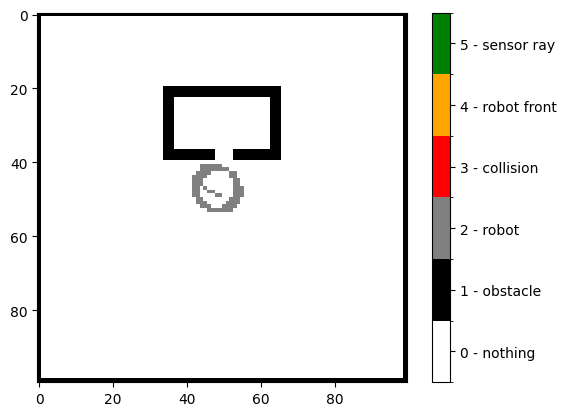

run no. 8 of 20
### iteration 0 / 501 ###
{'translations': 0.9599562237129033, 'rotations': 1.0, 'coverage': np.float64(0.0228), 'x_pos_end': 62.67879959733263, 'y_pos_end': 51.03447554059695, 'theta_end': 5010.0}


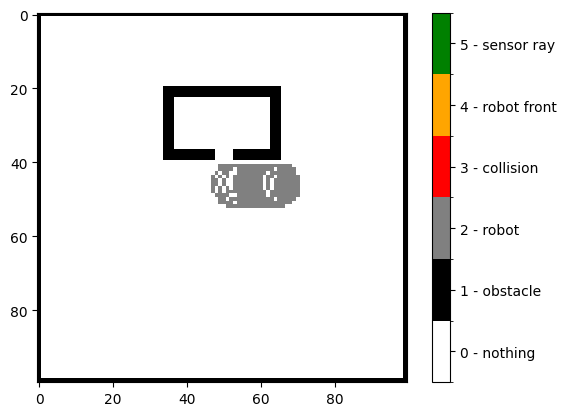

run no. 9 of 20
### iteration 0 / 501 ###
{'translations': 0.031936127744510934, 'rotations': 0.10677545701140437, 'coverage': np.float64(0.0015), 'x_pos_end': 35.47407133033609, 'y_pos_end': 40.70232712102702, 'theta_end': -80.27317563591646}


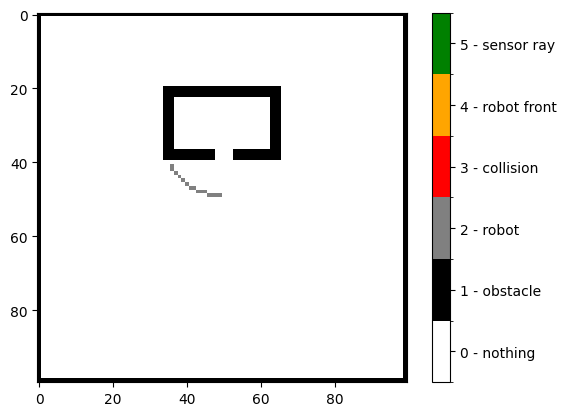

run no. 10 of 20
### iteration 0 / 501 ###
{'translations': 0.7199802375266889, 'rotations': 1.0, 'coverage': np.float64(0.0024), 'x_pos_end': 46.39441752622593, 'y_pos_end': 48.87127100023338, 'theta_end': -5010.0}


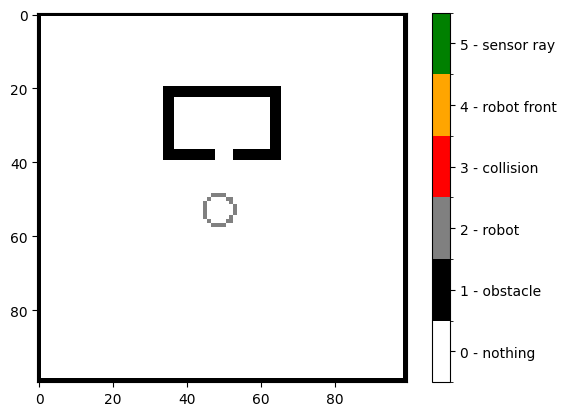

run no. 11 of 20
### iteration 0 / 501 ###
{'translations': 0.9984364540113685, 'rotations': 1.0, 'coverage': np.float64(0.0053), 'x_pos_end': 44.792163085897606, 'y_pos_end': 49.01566832099251, 'theta_end': -5010.0}


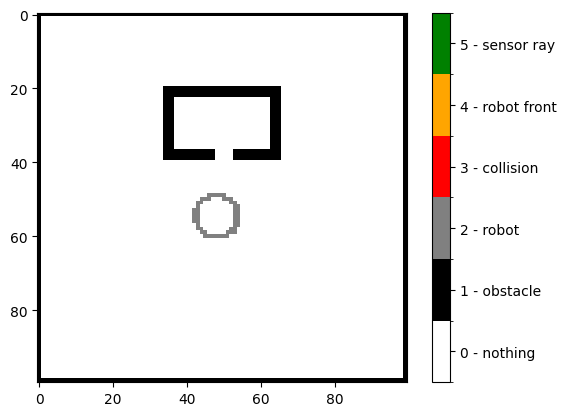

run no. 12 of 20
### iteration 0 / 501 ###
{'translations': 0.6055588845487375, 'rotations': 1.0, 'coverage': np.float64(0.0023), 'x_pos_end': 46.729042815780495, 'y_pos_end': 48.812267533257405, 'theta_end': -5010.0}


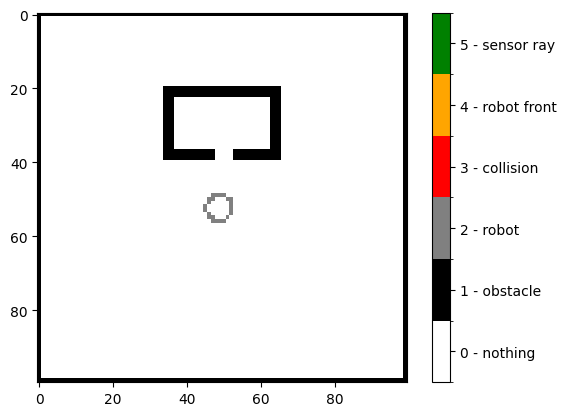

run no. 13 of 20
### iteration 0 / 501 ###
{'translations': 0.04711394607619927, 'rotations': 0.5287525799344687, 'coverage': np.float64(0.0004), 'x_pos_end': 48.14220747856611, 'y_pos_end': 49.34986630452705, 'theta_end': 2649.0504254717216}


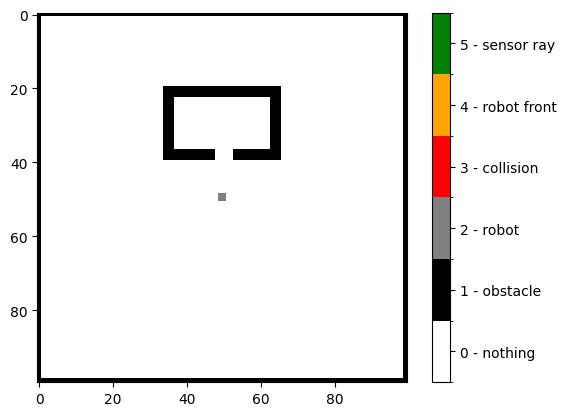

run no. 14 of 20
### iteration 0 / 501 ###
{'translations': 0.19941780277742274, 'rotations': 0.48060866152809273, 'coverage': np.float64(0.0017), 'x_pos_end': 50.83791349088922, 'y_pos_end': 51.679456017539074, 'theta_end': 2407.8493942557357}


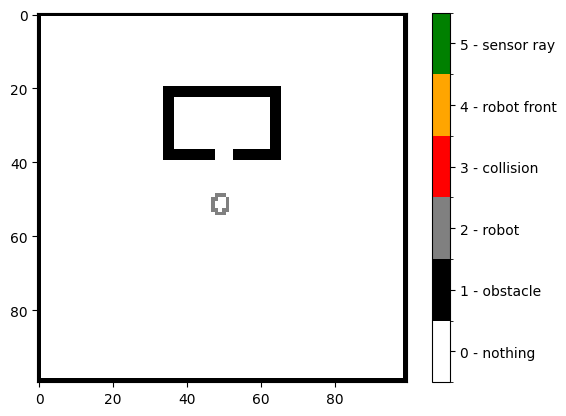

run no. 15 of 20
### iteration 0 / 501 ###
{'translations': 0.4248021689032883, 'rotations': 0.7001542904121092, 'coverage': np.float64(0.0124), 'x_pos_end': 42.59191428506894, 'y_pos_end': 49.47940596574159, 'theta_end': -3507.7729949647055}


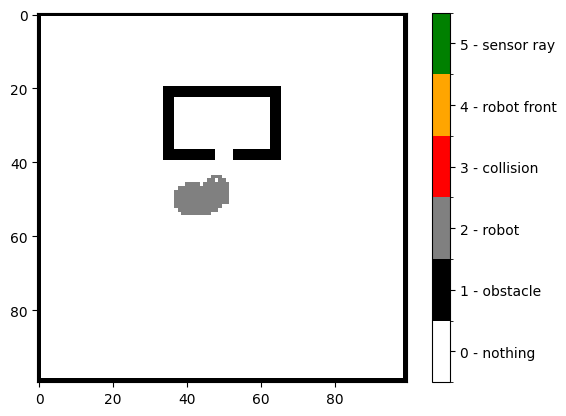

run no. 16 of 20
### iteration 0 / 501 ###
{'translations': 0.08403873637184689, 'rotations': 1.0, 'coverage': np.float64(0.0006), 'x_pos_end': 50.27079899783664, 'y_pos_end': 48.382620848614955, 'theta_end': -5010.0}


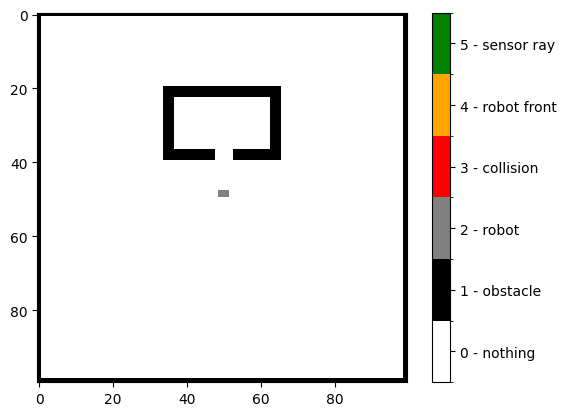

run no. 17 of 20
### iteration 0 / 501 ###
{'translations': 0.3496760558796597, 'rotations': 1.0, 'coverage': np.float64(0.0036), 'x_pos_end': 51.87245007373091, 'y_pos_end': 50.73393154128784, 'theta_end': -5010.0}


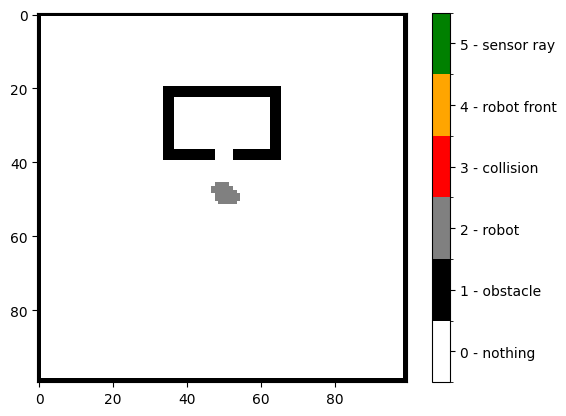

run no. 18 of 20
### iteration 0 / 501 ###
{'translations': 0.5039195902105847, 'rotations': 0.27706815733680606, 'coverage': np.float64(0.0262), 'x_pos_end': 75.59901336394161, 'y_pos_end': 2.0540887951945566, 'theta_end': 1285.1625071854555}


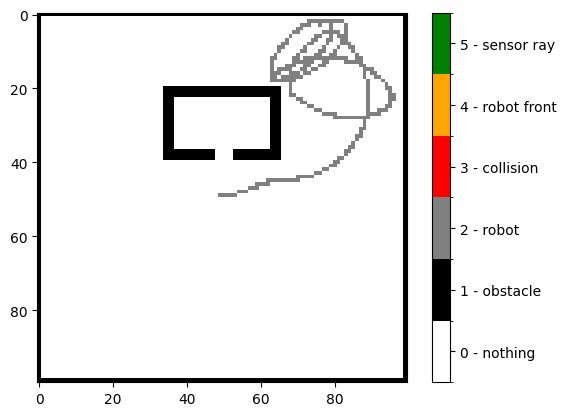

run no. 19 of 20
### iteration 0 / 501 ###
{'translations': 0.9999999999999999, 'rotations': 1.0, 'coverage': np.float64(0.0034), 'x_pos_end': 45.575499626201825, 'y_pos_end': 49.01566832099251, 'theta_end': -5010.0}


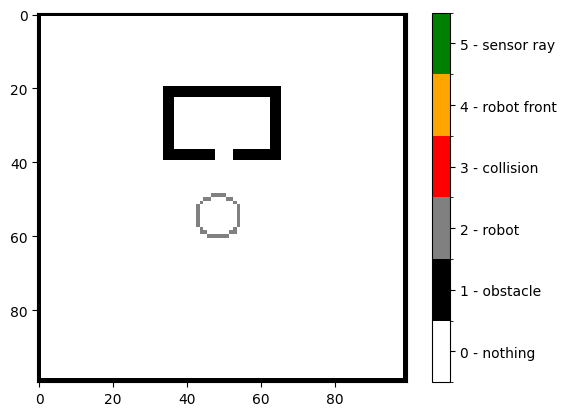

run no. 20 of 20
### iteration 0 / 501 ###
{'translations': 0.7159177805916552, 'rotations': 0.6344923179247879, 'coverage': np.float64(0.0077), 'x_pos_end': 50.179863204124366, 'y_pos_end': 51.300153536099494, 'theta_end': -3178.80651280319}


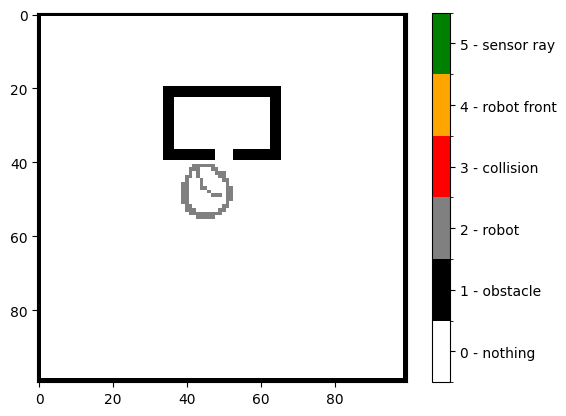

Terminé.


In [13]:

def my_controller_NN_4sensors(sensors):
  global weights
  translation = weights[0]*sensors[-2] + weights[1]*sensors[0] + weights[2]*sensors[2] + weights[3]*sensors[4] + weights[4]
  rotation = weights[5]*sensors[-2] + weights[6]*sensors[0] + weights[7]*sensors[2] + weights[8]*sensors[4] + weights[9]
  #print (sensors,translation,rotation,absolute_orientation)
  return translation,rotation

print ("#\n# random exploration of the policy space using a linear weighted combination of sensory inputs#")

display_arena=False # diplay step-by-step if True.
display_trace = True

init()
 
#clear_arena()
create_arena_walls()
create_wall_2(-20)

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

nb_runs = 20
max_iterations = 501

for i in range(nb_runs):
  print ("run no.",(i+1),"of",nb_runs)
  weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
  retValues = simulate(x_init,y_init,0,my_controller_NN_4sensors)
  print (retValues)
  show_trace()

print ("Terminé.")


In [ ]:
# parameters
#   initial x and y position and orientation
#   step controller function which returns translation/rotation (in [-1,1]) from sensors (in [0,1])
# returns:
#   sum of actual translations in [0,1]. Normalized over time and max translation.
#   sum of rotation, absolute value normalized value in [0,1]. Normalized over time and max rotation.
#   number of pixels of arena visited (unique location, ie. visited twice counts as 1)
#   particle's x coordinate at the end
#   particle's y coordinate at the end
#   fitness: average of Vtrans * (1 - |Vrot|) * min(sensors) over time
def simulate_modifier(x0,y0,orientation0,step):
    global x_particle,y_particle,absolute_orientation,trace

    clear_arena()
    clear_trace()

    x_particle, y_particle = x0, y0
    absolute_orientation = orientation0
    sensors = get_sensors(x_particle, y_particle,absolute_orientation)
    collision_array = place_particle(x_particle, y_particle,absolute_orientation)

    if collision_array is not None:
        print("[ERROR] initial location triggers collision.")
        sys.exit()

    iteration = 0
    log_sum_of_translation = 0 # logging
    log_sum_of_rotation = 0 # logging
    fitness_sum = 0.0  # accumulate fitness over time

    while iteration < max_iterations:
        if verbose_minimal_progress == True and iteration%gap_between_display_minimal_progress == 0:
            print ("### iteration",iteration,"/",max_iterations,"###")

        translation_per_step,rotation_per_step = step(sensors)

        log_sum_of_rotation += abs((max(-1.,min(+1.,rotation_per_step)))) # logging

        erase_particle(x_particle, y_particle)
        clean_sensors(x_particle, y_particle,absolute_orientation)
        backup_x_particle, backup_y_particle = x_particle, y_particle
        old_orientation = absolute_orientation   # record orientation before move

        x_particle, y_particle, absolute_orientation = update_particle_position(x_particle, y_particle, absolute_orientation, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration ,noiseFlag=False)
        sensors = get_sensors(x_particle, y_particle,absolute_orientation)
        collision_array = place_particle(x_particle, y_particle,absolute_orientation)

        # Initialize actual movement values
        actual_trans = 0.0
        actual_rot = 0.0

        if collision_array is not None: # collision occured
            if verbose == True:
                print("Collision detected!")
            if display_collision:
                print(collision_array)
            clean_sensors(x_particle, y_particle,absolute_orientation)
            x_particle, y_particle = backup_x_particle, backup_y_particle
            sensors = get_sensors(x_particle, y_particle,absolute_orientation)
            if display_collision:
                draw(collision_array)  # Draw the collision array
            absolute_orientation = update_particle_dynamics(x_particle, y_particle, absolute_orientation, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration, collision_array)
            place_particle(x_particle, y_particle,absolute_orientation)
            if verbose:
                print("Backtrack")
            # In case of collision, actual_trans and actual_rot remain 0
        else:
            # No collision: compute actual translation and rotation
            actual_trans = math.sqrt( ( x_particle - backup_x_particle )**2 + ( y_particle - backup_y_particle)**2 )
            actual_rot = absolute_orientation - old_orientation
            log_sum_of_translation += actual_trans  # logging

        # compute fitness contribution for this step
        norm_trans = actual_trans / max_translation_per_step
        norm_rot = abs(actual_rot) / max_rotation_per_step
        sensor_min = min(sensors)  # most stimulated sensor value (0 = obstacle touching, 1 = free)
        fitness_step = norm_trans * (1 - norm_rot) * sensor_min
        fitness_sum += fitness_step

        if display_arena == True:
            draw(arena)  # Draw the arena at each step
        if verbose == True:
            print(arena)
        iteration = iteration + 1

    log_pixels_visited = np.sum(trace == 2)

    retValues = {
        "translations": log_sum_of_translation/max_iterations,
        "rotations": log_sum_of_rotation/max_iterations,
        "coverage": log_pixels_visited/(arena_size**2),
        "x_pos_end": x_particle,
        "y_pos_end": y_particle,
        "theta_end": absolute_orientation,
        "fitness": fitness_sum / max_iterations   # average fitness per step
    }

    return retValues

#
# random exploration of the policy space using a linear weighted combination of sensory inputs#
run no. 1 of 200
### iteration 0 / 501 ###
fitness: 0.19367362311934042
run no. 2 of 200
### iteration 0 / 501 ###
fitness: 0.0
run no. 3 of 200
### iteration 0 / 501 ###
fitness: 0.5261089333138769
run no. 4 of 200
### iteration 0 / 501 ###
fitness: 0.4156921476070787
run no. 5 of 200
### iteration 0 / 501 ###
fitness: 0.0
run no. 6 of 200
### iteration 0 / 501 ###
fitness: 0.013527975731178414
run no. 7 of 200
### iteration 0 / 501 ###
fitness: 0.13726051808885503
run no. 8 of 200
### iteration 0 / 501 ###
fitness: 0.0
run no. 9 of 200
### iteration 0 / 501 ###
fitness: 0.0
run no. 10 of 200
### iteration 0 / 501 ###
fitness: 0.369197442355366
run no. 11 of 200
### iteration 0 / 501 ###
fitness: 0.6593392220031915
run no. 12 of 200
### iteration 0 / 501 ###
fitness: 0.07956194567694543
run no. 13 of 200
### iteration 0 / 501 ###
fitness: 0.16844001327638627
run no. 14 of 200
### iteratio

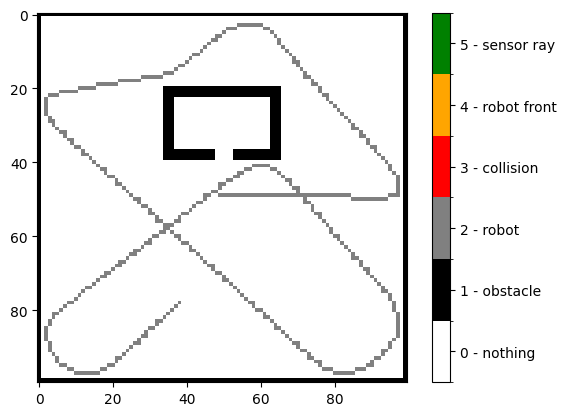

Statistiques finales: {'translations': 0.9713820659234527, 'rotations': 0.16570751338725004, 'coverage': np.float64(0.0455), 'x_pos_end': 37.84485477582456, 'y_pos_end': 77.30891306156084, 'theta_end': 762.5167018985929, 'fitness': 0.6916060429444694}


In [19]:
def my_controller_NN_4sensors(sensors):
    global weights
    translation = weights[0]*sensors[-2] + weights[1]*sensors[0] + weights[2]*sensors[2] + weights[3]*sensors[4] + weights[4]
    rotation = weights[5]*sensors[-2] + weights[6]*sensors[0] + weights[7]*sensors[2] + weights[8]*sensors[4] + weights[9]
    return translation, rotation

def fitness_function(params):
    global weights, x_init, y_init, theta_init
    weights = params
    ret = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    return ret['fitness']

print("#\n# random exploration of the policy space using a linear weighted combination of sensory inputs#")

display_arena = False
display_trace = True

init()
create_arena_walls()
create_wall_2(-20)

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

nb_runs = 200
max_iterations = 501

best_fitness = -float('inf')
best_params = None

for i in range(nb_runs):
    print("run no.", (i+1), "of", nb_runs)
    weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
    fit = fitness_function(weights)
    if fit > best_fitness:
        best_fitness = fit
        best_params = weights.copy()
    print("fitness:", fit)

print("Meilleure fitness:", best_fitness)
print("Meilleurs paramètres:", best_params)

print("\nReplay du meilleur individu")
weights = best_params
ret = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
show_trace()
print("Statistiques finales:", ret)

Q2.1 En exécutant la recherche aléatoire, on constate que la politique change radicalement entre chaque essai car les poids sont tirés au hasard. Certains robots tournent sur eux-mêmes (rotation élevée), d'autres avancent rapidement. La direction préférentielle n'est pas unique, mais le meilleur individu obtenu présente une translation élevée et une faible rotation, ce qui correspond à l'objectif de maximiser le déplacement.

Q2.2 Nous avons modifié le code pour calculer la fitness de déplacement (maximiser la vitesse de translation et minimiser la rotation) et effectué 200 essais. Le meilleur individu a une fitness de 0,6916, avec une translation moyenne de 0,971 et une rotation moyenne de 0,166.

Q2.3 En rejouant ce meilleur individu, on observe sa trajectoire (couverture de 4,55 %) et sa position finale (x ≈ 37,8 , y ≈ 77,3). Les statistiques obtenues confirment que ce robot se déplace efficacement avec peu de rotations.

---
---
---

#<font color="orange">Partie 3. Evolution</font>

A partir du code précédent, nous allons maintenant implémenter deux algorithmes d'évolution artificielle vue lors de la séance précédente: (1+1)-ES et CMAES (n'hésitez pas à faire des copier-coller). Pour ne pas alourdir l'affichage, vous pouvez vous contenter d'afficher uniquement la valeur de la fitness pour chaque individu évalué pendant l'évolution.

<font color="red">EXERCICES :</font>

- en utilisant le code que vous avez réalisé lors du dernier TP, implémentez l'algorithme (1+1)-ES (avec la règle des 1/5e si vous l'avez fait) pour optimiser la fitness de déplacement précédemment implémentée. Lancez l'algorithme sur 200 itérations, affichez le meilleur résultat (performance et graphes).

- Idem avec CMAES. Pour limiter le budget d'évaluations de CMAES vous pouvez utiliser la commande *es.opts.set({'maxfevals': mon_budget_en_evaluations})*. A noter que CMAES s'arrétera *à la fin* de la première génération qui aura épuisée le budget d'évaluations, ie. le nombre d'évaluations effective peut dépasser la limite prévue par le budget -- on considère que c'est négligeable ici.

- Comparez (1+1)-ES et CMAES en générant les courbes montrant l'évolution des best-evers au cours du temps pour chaque algorithmes.

# (1+1)-ES 1/5th rule


#
# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#
it =    20, current_fit = 9.7017e-02, best_fit = 9.8510e-02, sigma = 1.3454e-03
it =    40, current_fit = 1.0558e-01, best_fit = 4.6932e-01, sigma = 1.0240e-01
it =    60, current_fit = 1.4966e-02, best_fit = 6.4193e-01, sigma = 2.4355e-01
it =    80, current_fit = 7.0719e-01, best_fit = 7.0719e-01, sigma = 4.3054e-02
it =   100, current_fit = 6.5062e-01, best_fit = 7.2005e-01, sigma = 1.8102e-02
it =   120, current_fit = 7.1744e-01, best_fit = 7.2419e-01, sigma = 1.3454e-03
it =   140, current_fit = 3.4762e-01, best_fit = 7.2449e-01, sigma = 1.0000e-04
it =   160, current_fit = 5.3482e-01, best_fit = 7.2457e-01, sigma = 1.7678e-05
it =   180, current_fit = 7.2458e-01, best_fit = 7.2460e-01, sigma = 3.1250e-06
it =   200, current_fit = 7.2460e-01, best_fit = 7.2460e-01, sigma = 1.3139e-06

Rejoue et affiche la meilleure solution
{'translations': 1.0, 'rotations': 0.2632164621373232, 'coverage': np.float64(0.045

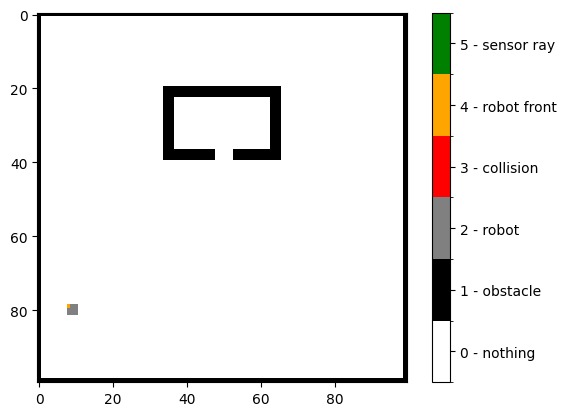

# Trajectory


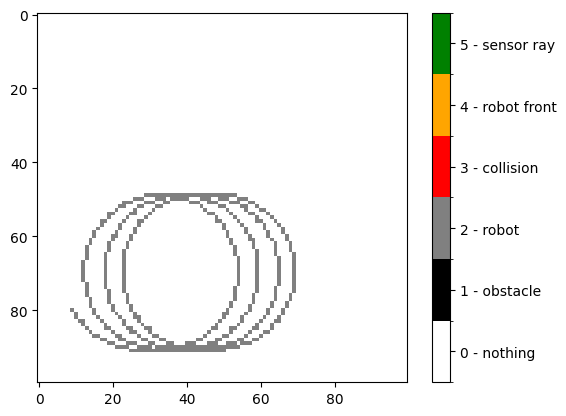

Terminé.


In [24]:

def my_controller_NN_4sensors(sensors):
  global weights
  translation = weights[0]*sensors[-2] + weights[1]*sensors[0] + weights[2]*sensors[2] + weights[3]*sensors[4] + weights[4]
  rotation = weights[5]*sensors[-2] + weights[6]*sensors[0] + weights[7]*sensors[2] + weights[8]*sensors[4] + weights[9]
  #print (sensors,translation,rotation,absolute_orientation)
  return translation,rotation

def launch_oneplusone_withOneFifthRule(individual, sigma_init, nbeval, display, ma_func):
    """
    (1+1)-ES with 1/5 rule for MAXIMIZATION.
    individual : initial solution (list or array)
    sigma_init : initial step size
    nbeval     : total number of evaluations (including initial)
    display    : if True, print progress every 10% of evaluations
    ma_func    : fitness function to MAXIMIZE (returns a scalar)
    Returns: besteverIt, besteverFit, besteverSolution, data
    """
    x = np.array(individual, dtype=float)
    best_fit = ma_func(x)                     # evaluate initial solution
    best_x = x.copy()
    sigma = sigma_init
    data = [best_fit]                         # track best fitness over time

    for i in range(1, nbeval):
        # Generate offspring by adding Gaussian noise
        x_prime = x + sigma * np.random.randn(*x.shape)
        fit_prime = ma_func(x_prime)

        # Selection for MAXIMIZATION: accept if offspring is better or equal
        if fit_prime >= best_fit:
            x = x_prime
            best_fit = fit_prime
            best_x = x.copy()
            # Success: increase sigma (with upper bound)
            sigma = min(sigma * 2, 2.0)
        else:
            # Failure: decrease sigma (with lower bound)
            sigma = max(sigma * (2 ** (-0.25)), 1e-10)

        data.append(best_fit)

        # Display progress every 10% of total evaluations
        if display and i % max(1, nbeval // 10) == 0:
            print(f"it = {i:5d}, current_fit = {fit_prime:.4e}, best_fit = {best_fit:.4e}, sigma = {sigma:.4e}")

    besteverIt = nbeval - 1                     # last iteration index
    besteverFit = best_fit
    besteverSolution = best_x.tolist()
    return besteverIt, besteverFit, besteverSolution, data

def my_fitness_func_maximize(params):
    global x_init, y_init, theta_init, weights
    weights = params
    retValues = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    fitness = retValues['fitness']
    if display_trace:
        show_trace()
    return fitness

# Main

print ("#\n# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#")

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = False # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
display_trace = False

init()

#clear_arena()
create_arena_walls()
create_wall_2(-20)

max_iterations = 501 # nb of simulation iterations for one robot
max_iterations_evolve = 201 # nb of evolution iterations

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

initial_solution = np.random.uniform(-1.0, 1.0, size=10).tolist()
besteverIt,besteverFit,besteverSolution,data = launch_oneplusone_withOneFifthRule(initial_solution,nbeval=max_iterations_evolve,sigma_init=0.0001,display=True,ma_func=my_fitness_func_maximize)

print ("\nRejoue et affiche la meilleure solution")
weights = np.copy(besteverSolution).tolist()
retValues = simulate_modifier(x_init,y_init,theta_init,my_controller_NN_4sensors)

print (retValues)
print ("# Final state")
show_arena()
print ("# Trajectory")
show_trace()
print ("Terminé.")


# CMAES




=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=978835, Thu Mar 19 16:12:19 2026)
0 : 0.0
1 : 0.002399812814148644
2 : 0.21533379932902022
3 : 0.36551878255303843
4 : 0.0
5 : 0.07210399855986806
6 : 0.0
7 : 0.0
8 : 0.0400557336038707
9 : 0.013223167851421753
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -3.655187825530384e-01 1.0e+00 4.79e-01  5e-01  5e-01 0:00.9
10 : 0.0
11 : 0.5430248438380326
12 : 0.0
13 : 0.40561802299413885
14 : 0.44875332110369
15 : 0.0
16 : 0.0
17 : 0.0
18 : 0.0
19 : 0.024869173453975952
    2     20 -5.430248438380326e-01 1.2e+00 5.22e-01  5e-01  6e-01 0:01.7
20 : 0.16452350740503235
21 : 0.07460724310803733
22 : 0.402879673608081
23 : 0.0
24 : 0.12712695327736803
25 : 0.2704180038727612
26 : 0.0
27 : 0.0005226643483807322
28 : 0.0032171523752023774
29 : 0.6294179384993646
    3     30 -6.294179384993646e-01 1.4e+00 5.65e-01  5e-01  6e-01 0:02.5
30 : 0.018890999536

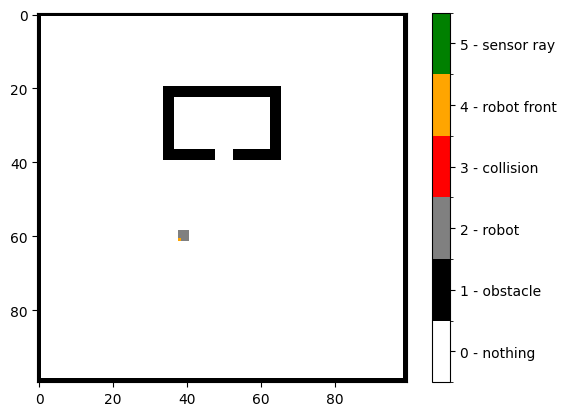

# Trajectory


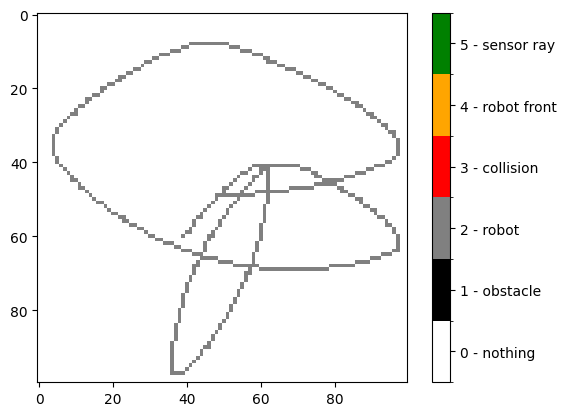

Terminé.


In [31]:
def my_fitness_func_for_cmaes(params):
    global x_init, y_init, theta_init, weights, eval
    weights = params
    retValues = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    fitness = retValues['fitness']          
    if display_trace:
        show_trace()
    print(eval, ":", fitness)
    eval += 1
    return -fitness                          

def launch_cmaes(dim, display, ma_func, max_evaluations):
    import cma
    x0 = np.random.uniform(-1, 1, dim)
    sigma0 = 0.5
    es = cma.CMAEvolutionStrategy(x0, sigma0)
    es.opts.set({'maxfevals': max_evaluations})
    es.opts.set({
        'verbose': -1 if not display else 1,
        'verb_disp': max(1, max_evaluations // 10),
        'tolfun': 0,
        'tolx': 0,
        'tolconditioncov': 0,
    })
    
    best_history = []
    def callback(es):
        best_history.append((es.countevals, es.best.f))
    
    es.optimize(ma_func, callback=callback)
    if display:
        es.result_pretty()
    return es.result.fbest, es.result.xbest, best_history

display_arena = False
verbose_minimal_progress = False
display_trace = False

arena_size = 100
max_translation_per_step = 1.0
max_rotation_per_step = 10.0
max_iterations = 501
max_iterations_evolve = 201  

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

init()
create_arena_walls()
create_wall_2(-20)

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams, best_history = launch_cmaes(
    dim=10,
    display=False,
    ma_func=my_fitness_func_for_cmaes,
    max_evaluations=max_iterations_evolve
)

print("besteverFitness (CMA-ES objective, negative of actual):", besteverFitness)
actual_fitness = -besteverFitness
print("Actual best fitness:", actual_fitness)
print("besteverParams:", besteverParams)

weights = besteverParams
retValues = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")

# Replay

A toutes fins utiles, exécutez cette cellule pour obtenir un replay (avec affichage pas à pas si display_arena=True) de la trajectoire du robot avec les meilleurs paramètres. Veillez à ce que *besteverParams* contienne bien les paramètres voulus (ce qui est le cas si vous venez d'exécutez la cellule précédente).

besteverFitness -0.7176473250181633
besteverParams [-1.8816613  -0.3472094  -0.21521833 -1.02356626 -0.63857566  1.00792573
  0.36144647  0.47671971 -0.11237043 -1.45136879]


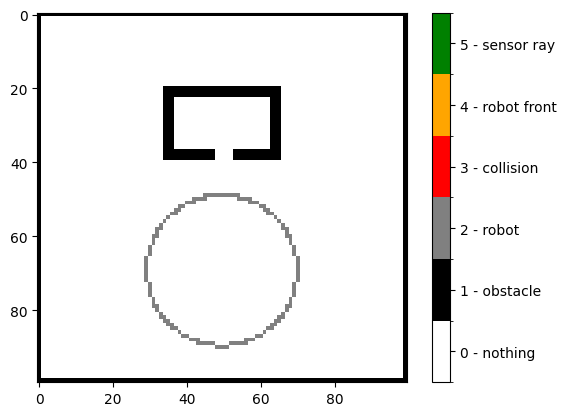

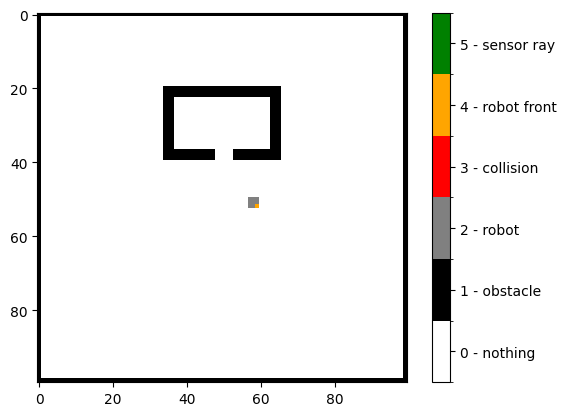


Statistiques:
	 translations      : 1.0
	 rotations         : 0.2823526749818368
	 couverture        : 0.0138
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 57.2548787486958 , 50.24856886498277 , 1414.5869016589859 )



In [28]:

# initial conditions

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

display_trace = True
display_arena = False

init() # perform only once
create_arena_walls()
create_wall_2(-20)

print ("besteverFitness",besteverFitness)
print ("besteverParams",besteverParams)

weights = besteverParams
retValues = simulate_modifier(x_init,y_init,theta_init,my_controller_NN_4sensors)
show_trace()
show_arena()

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ("\t position initiale : (",x_init,",",y_init,",",theta_init,")" ) # init: x,y,\theta
print ("\t position finale   : (",retValues['x_pos_end'],",",retValues['y_pos_end'],",",retValues['theta_end'],")" ) # final: init: x,y,\theta
print ()

#
# (1+1)-ES 1/5th rule for maximising translation and minimising rotation#
it =    20, current_fit = 5.6734e-01, best_fit = 5.8609e-01, sigma = 1.0000e-04
it =    40, current_fit = 5.2496e-01, best_fit = 5.9409e-01, sigma = 1.7678e-05
it =    60, current_fit = 5.9324e-01, best_fit = 5.9409e-01, sigma = 5.5243e-07
it =    80, current_fit = 5.9380e-01, best_fit = 5.9409e-01, sigma = 9.7656e-08
it =   100, current_fit = 5.9380e-01, best_fit = 5.9409e-01, sigma = 9.7656e-08
it =   120, current_fit = 5.9409e-01, best_fit = 5.9409e-01, sigma = 4.1059e-08
it =   140, current_fit = 5.9409e-01, best_fit = 5.9409e-01, sigma = 3.0518e-09
it =   160, current_fit = 5.9409e-01, best_fit = 5.9409e-01, sigma = 3.0518e-09
it =   180, current_fit = 5.9409e-01, best_fit = 5.9409e-01, sigma = 1.2831e-09
it =   200, current_fit = 5.9409e-01, best_fit = 5.9409e-01, sigma = 2.2682e-10
(1+1)-ES finished. Best fitness: 0.5941

=-=-=-=-= Robot with CMA-ES =-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimens

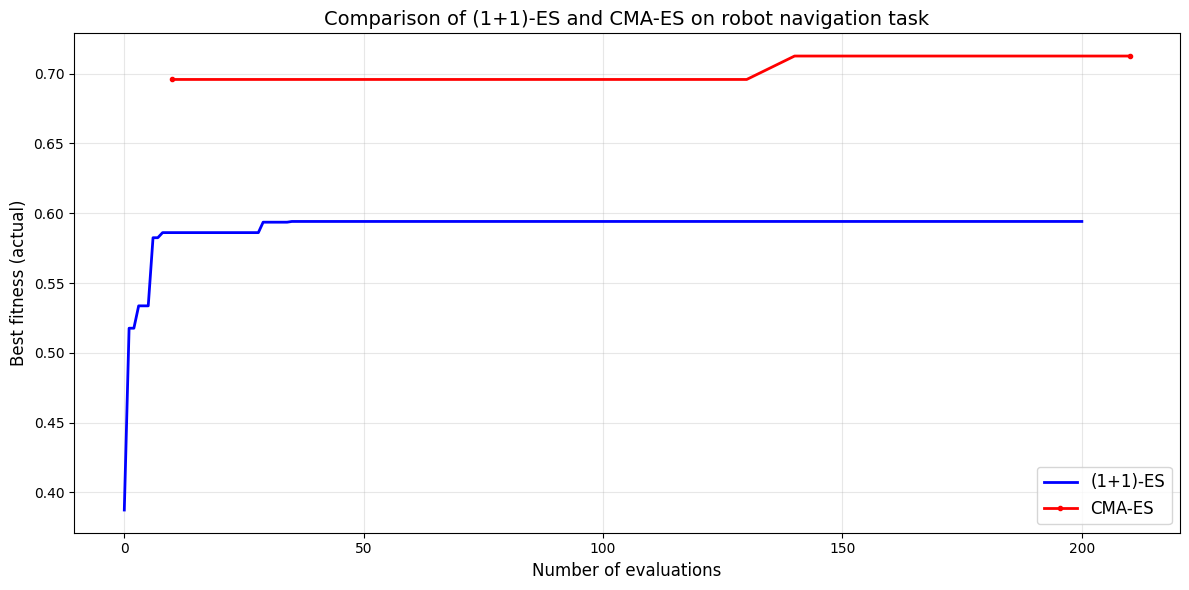


Replay of the best CMA-ES individual:
{'translations': 1.0, 'rotations': np.float64(0.28741035190127423), 'coverage': np.float64(0.015), 'x_pos_end': 48.52578981932688, 'y_pos_end': 48.49936971792526, 'theta_end': np.float64(1439.9258630253853), 'fitness': np.float64(0.7125896480987357)}
# Final state


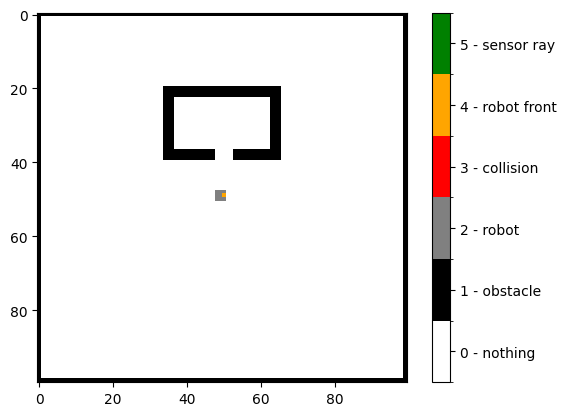

# Trajectory


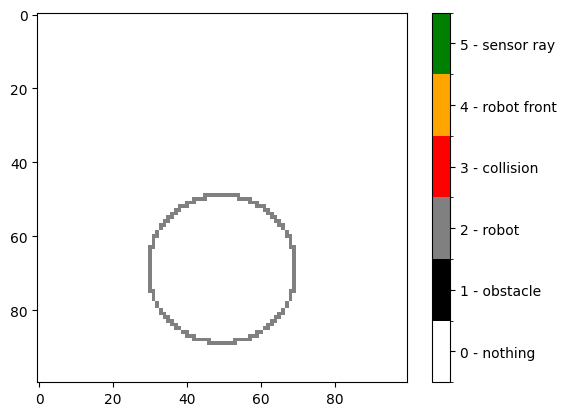

Terminé.


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------- (1+1)-ES --------------------
print("#\n# (1+1)-ES 1/5th rule for maximising translation and minimising rotation#")

display_arena = False
verbose_minimal_progress = False
display_trace = False

init()
create_arena_walls()
create_wall_2(-20)

max_iterations = 501
max_iterations_evolve = 201

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

initial_solution = np.random.uniform(-1.0, 1.0, size=10).tolist()
besteverIt, besteverFit, besteverSolution, data_ones = launch_oneplusone_withOneFifthRule(
    initial_solution,
    nbeval=max_iterations_evolve,
    sigma_init=0.0001,
    display=True,
    ma_func=my_fitness_func_maximize
)

print(f"(1+1)-ES finished. Best fitness: {besteverFit:.4f}")

# -------------------- CMA-ES --------------------
print("\n=-=-=-=-= Robot with CMA-ES =-=-=-=-=")


init()
create_arena_walls()
create_wall_2(-20)

eval = 0

besteverFitness, besteverParams, best_history = launch_cmaes(
    dim=10,
    display=False,
    ma_func=my_fitness_func_for_cmaes,
    max_evaluations=max_iterations_evolve
)

actual_fitness = -besteverFitness
print(f"CMA-ES finished. Best fitness (actual): {actual_fitness:.4f}")

ones_evals = list(range(len(data_ones)))
ones_best = data_ones

cma_evals = [h[0] for h in best_history]          
cma_best = [-h[1] for h in best_history]          

plt.figure(figsize=(12, 6))
plt.plot(ones_evals, ones_best, label='(1+1)-ES', linewidth=2, color='blue')
plt.plot(cma_evals, cma_best, label='CMA-ES', linewidth=2, color='red', marker='o', markersize=3, markevery=20)
plt.xlabel('Number of evaluations', fontsize=12)
plt.ylabel('Best fitness (actual)', fontsize=12)
plt.title('Comparison of (1+1)-ES and CMA-ES on robot navigation task', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\nReplay of the best CMA-ES individual:")
weights = besteverParams
retValues = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")

Q3.1 (1+1)-ES a atteint une fitness maximale d'environ 0,594 après 200 itérations, tandis que CMA-ES a obtenu une fitness d'environ 0,713. Les courbes montrent que CMA-ES converge plus rapidement et trouve une meilleure solution.

Q3.2 Les meilleurs individus des deux algorithmes présentent des translations élevées et des rotations faibles, mais des couvertures faibles (environ 4,5 % pour (1+1)-ES et 1,5 % pour CMA-ES).

---
---
---

#<font color="orange">Partie 4. Robustesse et généralisation</font>

Nous avons jusqu'ici utilisé les mêmes valeurs pour la position et l'orientation initiale. Cependant cela peut provoquer un surapprentissage dépendant de ces conditions initiales. C'est ce que nous allons étudier ici.

<font color="red">EXERCICES :</font>

- Testez le résultat obtenu précédemment par CMAES (ie. sans relancer l'optimisation) en utilisant *create_wall_2()* à la place de *create_wall_2(-20)* pour construire l'environnement. Exécutez et commentez le résultat.

- Relancez l'optimisation avec CMAES en utilisant *create_wall_2()* comme condition initiale. Commentez le résultat.

- Modifier l'évaluation d'un individu pour choisir aléatoire le point de départ du robot: soit au centre de l'arène, soit au centre de la mini-arène définie par *create_wall_2(-20)*. Qu'observez-vous? Commentez. en particulier: comment faire mieux dans le cas général?




Partie 4. Robustesse et généralisation


--- Exercice 1: Test du meilleur individu dans le nouvel environnement (sans décalage) ---
Environnement: create_wall_2() (sans décalage)
Résultats de la simulation avec les meilleurs paramètres:
{'translations': 0.023952095808383218, 'rotations': np.float64(0.22036069613178114), 'coverage': np.float64(0.0013), 'x_pos_end': 38.40617549356554, 'y_pos_end': 43.29458894933396, 'theta_end': np.float64(-97.82943258677695), 'fitness': np.float64(0.005167466379448933)}
Trajectoire:


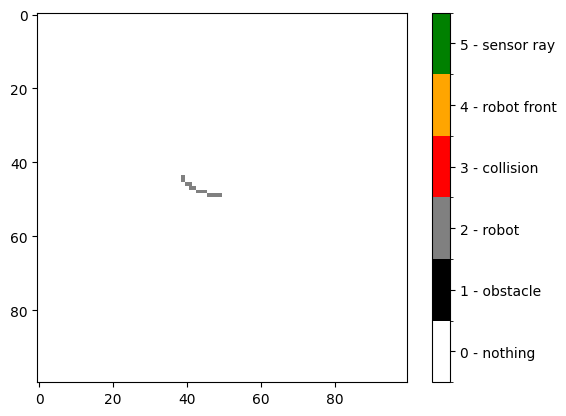

État final:


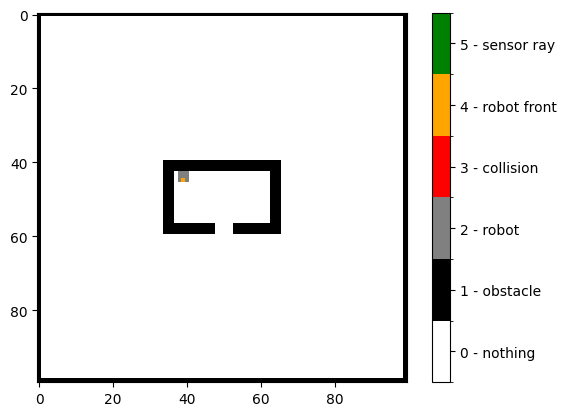


--- Exercice 2: Ré-optimisation avec CMA-ES dans le nouvel environnement ---
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1060110, Thu Mar 19 16:48:54 2026)
0 : 0.011749545624294705
1 : 0.008702290973149701
2 : 0.0036382556380082703
3 : 0.010444068483339312
4 : 0.01083309946519283
5 : -1.4228878641145887e-05
6 : 0.0007199659600345348
7 : 0.0
8 : 0.0039481296456234044
9 : 0.005560522392520141
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -1.174954562429470e-02 1.0e+00 4.68e-01  4e-01  5e-01 0:01.2
10 : -0.012396137706900923
11 : 0.00905297051734883
12 : 0.07154884595701934
13 : 0.00461611155466337
14 : 4.464911446757e-05
15 : 0.008624942460905734
16 : 0.004612335536941499
17 : 0.0016273473181534451
18 : 0.010257353610058724
19 : 0.0007351408270129174
    2     20 -7.154884595701934e-02 1.1e+00 4.23e-01  4e-01  4e-01 0:02.2
20 : 0.0014844577369619624
21 : 0.09514561407433235
22 : 0.01100258763984445
23 : 0.0026129988890587308
24 : 0.02

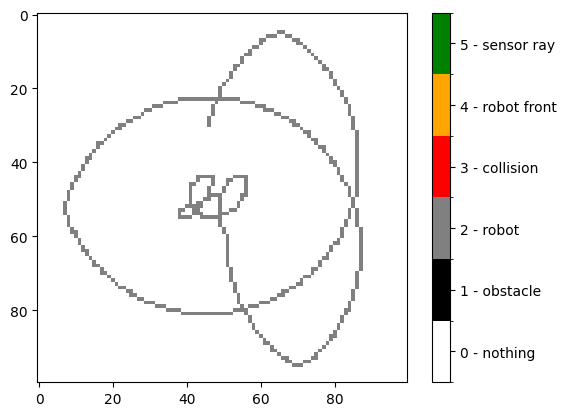

État final:


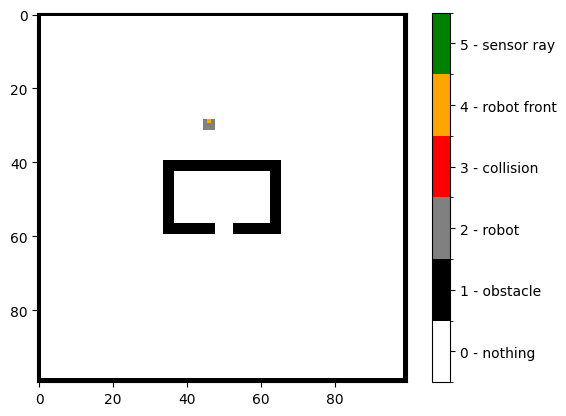


--- Exercice 3: Optimisation avec position de départ aléatoire ---
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1040218, Thu Mar 19 16:49:14 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -9.159550766240850e-02 1.0e+00 4.36e-01  4e-01  4e-01 0:00.8
    2     20 -3.658630614148351e-01 1.2e+00 4.20e-01  4e-01  4e-01 0:01.7
    3     30 -2.044935757490267e-01 1.3e+00 4.13e-01  4e-01  4e-01 0:02.6
    7     70 -5.391014552439546e-01 1.6e+00 4.60e-01  4e-01  5e-01 0:06.2
   12    120 -6.479946235629910e-01 2.1e+00 4.98e-01  4e-01  6e-01 0:10.8
   18    180 -6.802776533895909e-01 3.0e+00 4.81e-01  4e-01  6e-01 0:16.1
   20    200 -6.850273495356187e-01 3.3e+00 5.13e-01  4e-01  6e-01 0:18.0
   21    210 -4.511342041929267e-01 3.3e+00 5.33e-01  5e-01  7e-01 0:19.0
termination on {'maxfevals': 201}
final/bestever f-value = -4.511342e-01 -8.127571e-01 after 210/145 evaluations
incumbent solution: [ 0.04622665  2.16097363 -0.27092968 -1.41

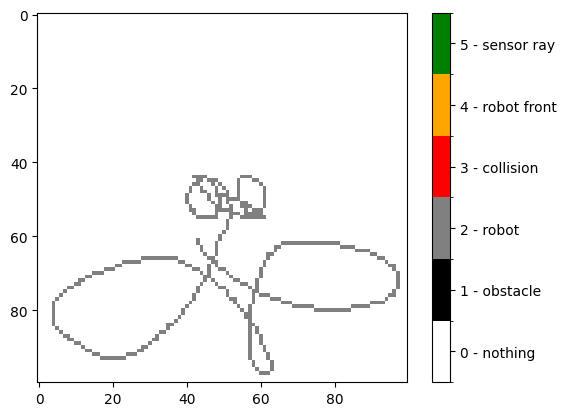

Départ dans la zone décalée:
{'translations': 0.9999999999999999, 'rotations': np.float64(0.1586158604200069), 'coverage': np.float64(0.0428), 'x_pos_end': 88.64611290120735, 'y_pos_end': 28.990096973306166, 'theta_end': np.float64(-774.5411837985225), 'fitness': np.float64(0.8127570982803999)}


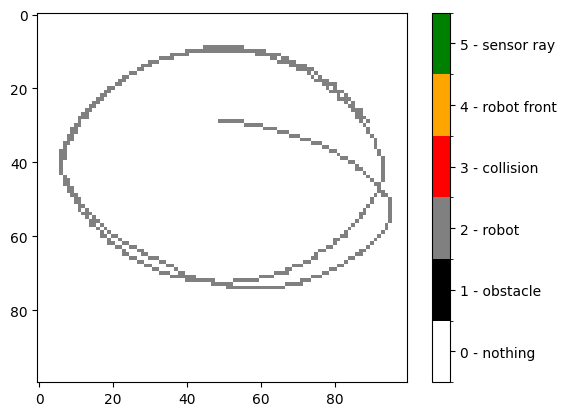


Terminé.


In [35]:
# ==================== Partie 4. Robustesse et généralisation ====================

print("\n" + "="*50)
print("Partie 4. Robustesse et généralisation")
print("="*50 + "\n")

arena_size = 100
max_translation_per_step = 1.0
max_rotation_per_step = 10.0
max_iterations = 501
max_iterations_evolve = 201

x_center = arena_size//2 - particle_box/2
y_center = arena_size//2 - particle_box/2
theta_init = 0

# -------------------- Exercice 1 --------------------
print("\n--- Exercice 1: Test du meilleur individu dans le nouvel environnement (sans décalage) ---")
if 'besteverParams' in globals():
    weights = besteverParams
    init()
    create_arena_walls()
    create_wall_2()
    print("Environnement: create_wall_2() (sans décalage)")
    ret = simulate_modifier(x_center, y_center, theta_init, my_controller_NN_4sensors)
    print("Résultats de la simulation avec les meilleurs paramètres:")
    print(ret)
    print("Trajectoire:")
    show_trace()
    print("État final:")
    show_arena()
else:
    print("besteverParams n'existe pas. Veuillez d'abord exécuter la partie CMA-ES.")

# -------------------- Exercice 2 --------------------
print("\n--- Exercice 2: Ré-optimisation avec CMA-ES dans le nouvel environnement ---")
init()
create_arena_walls()
create_wall_2()

eval = 0

def my_fitness_func_fixed(params):
    global x_center, y_center, theta_init, weights, eval
    weights = params
    ret = simulate_modifier(x_center, y_center, theta_init, my_controller_NN_4sensors)
    print(eval, ":", ret['fitness'])
    eval += 1
    return -ret['fitness']

bestFitness2, bestParams2, bestHistory2 = launch_cmaes(
    dim=10,
    display=False,
    ma_func=my_fitness_func_fixed,
    max_evaluations=max_iterations_evolve
)
actual_fitness2 = -bestFitness2
print(f"CMA-ES terminé. Meilleure fitness réelle: {actual_fitness2:.4f}")
print("Meilleurs paramètres:", bestParams2)

weights = bestParams2
ret2 = simulate_modifier(x_center, y_center, theta_init, my_controller_NN_4sensors)
print("Résultats du meilleur individu dans le nouvel environnement:")
print(ret2)
print("Trajectoire:")
show_trace()
print("État final:")
show_arena()

# -------------------- Exercice 3 --------------------
print("\n--- Exercice 3: Optimisation avec position de départ aléatoire ---")
init()
create_arena_walls()
create_wall_2()

def my_fitness_func_random_start(params):
    global weights, theta_init
    weights = params
    if np.random.rand() < 0.5:
        x = arena_size//2 - particle_box/2
        y = arena_size//2 - particle_box/2
    else:
        x = arena_size//2 - particle_box/2
        y = arena_size//2 - particle_box/2 - 20
    ret = simulate_modifier(x, y, theta_init, my_controller_NN_4sensors)
    # print(f"eval {eval}: start=({x},{y}), fitness={ret['fitness']:.4f}")
    return -ret['fitness']

eval = 0

bestFitness3, bestParams3, bestHistory3 = launch_cmaes(
    dim=10,
    display=False,
    ma_func=my_fitness_func_random_start,
    max_evaluations=max_iterations_evolve
)
actual_fitness3 = -bestFitness3
print(f"CMA-ES avec positions aléatoires terminé. Meilleure fitness réelle: {actual_fitness3:.4f}")
print("Meilleurs paramètres:", bestParams3)

print("\nTest du meilleur individu à deux positions de départ différentes:")
weights = bestParams3

ret_center = simulate_modifier(x_center, y_center, theta_init, my_controller_NN_4sensors)
print("Départ au centre:")
print(ret_center)
show_trace()

x_off = arena_size//2 - particle_box/2
y_off = arena_size//2 - particle_box/2 - 20
ret_off = simulate_modifier(x_off, y_off, theta_init, my_controller_NN_4sensors)
print("Départ dans la zone décalée:")
print(ret_off)
show_trace()

print("\nTerminé.")

Q4.1 En raison des changements d'environnement (emplacement différent des obstacles), le robot peut avoir des difficultés d'adaptation, ce qui se traduit par une baisse de ses performances, une augmentation des collisions ou une exploration limitée. Ceci confirme le surapprentissage de la stratégie par rapport à l'environnement d'entraînement.

Q4.2 L'optimisation doit trouver une stratégie adaptée au nouvel environnement, avec un niveau d'adaptation proche ou supérieur à la valeur précédente. Cependant, si le nouvel environnement est plus complexe, le niveau d'adaptation peut être légèrement inférieur.

Q4.3 Choisir aléatoirement le point de départ pour chaque évaluation revient à soumettre l'individu à de multiples conditions initiales, réduisant ainsi l'objectif d'optimisation à une performance moyenne. Une meilleure approche consisterait à exécuter l'algorithme plusieurs fois avec différents points de départ aléatoires pour chaque évaluation, puis à calculer la moyenne des résultats, mais cela augmenterait le coût de calcul. On peut également randomiser la direction de départ.


---
---
---

#<font color="orange">Partie 5. Fonctions objectifs et tâches</font>

A partir de cet exercice, vous pouvez augmentez (si vous le souhaitez) le budget d'évaluations utilisé. Pour cet exercice, on utilisera *create_wall_1* pour construire l'environnement initial. La position initiale du robot sera au centre de l'arène et son orientation sera de zéro (comme au début).

<font color="red">EXERCICES :</font>

- Vous remarquerez que la fonction simulation retourne un score de couverture. Avec CMAES, optimisez la politique pour maximiser ce score de couverture en l'utilisant comme valeur de fitness.

- Le score de couverture est une bonne mesure de la qualité d'une stratégie existante, mais pas forcément un bon guide pour l'optimisation. Ecrivez une fonction maximisant la couverture, c'est-à-dire qui ne contiendra pas forcément le score de couverture, mais aussi d'autres éléments pouvant guider l'optimisation, combiné ou non avec le score de couverture. Vous comparerez avec les résultats obtenus avec le score de couverture originel et ceux obtenus avec votre fonction fitness. Vous utiliserez le score de couverture pour tracer la performance des best-ever au cours de l'évolution dans les deux cas, afin que les résultats soient interprétables.




Partie 5. Optimisation de la couverture

--- Optimisation avec fitness = -coverage ---
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=977406, Thu Mar 19 17:02:19 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -4.160000000000000e-02 1.0e+00 4.65e-01  4e-01  5e-01 0:00.9
    2     20 -4.330000000000000e-02 1.2e+00 4.37e-01  4e-01  4e-01 0:01.7
    3     30 -4.290000000000000e-02 1.2e+00 4.21e-01  4e-01  4e-01 0:02.6
    7     70 -4.560000000000000e-02 1.5e+00 4.28e-01  4e-01  4e-01 0:05.8
   12    120 -4.590000000000000e-02 2.0e+00 4.51e-01  4e-01  5e-01 0:09.9
   19    190 -4.670000000000000e-02 2.7e+00 3.10e-01  3e-01  3e-01 0:15.6
   27    270 -4.670000000000000e-02 4.1e+00 2.95e-01  2e-01  4e-01 0:21.9
   36    360 -4.680000000000000e-02 6.8e+00 5.23e-01  4e-01  9e-01 0:28.9
   47    470 -4.700000000000000e-02 1.1e+01 5.19e-01  4e-01  9e-01 0:37.6
   50    500 -4.680000000000000e-02 1.1e+01 4.40e-01  4e-01  7e-01 0:39.9
   51   

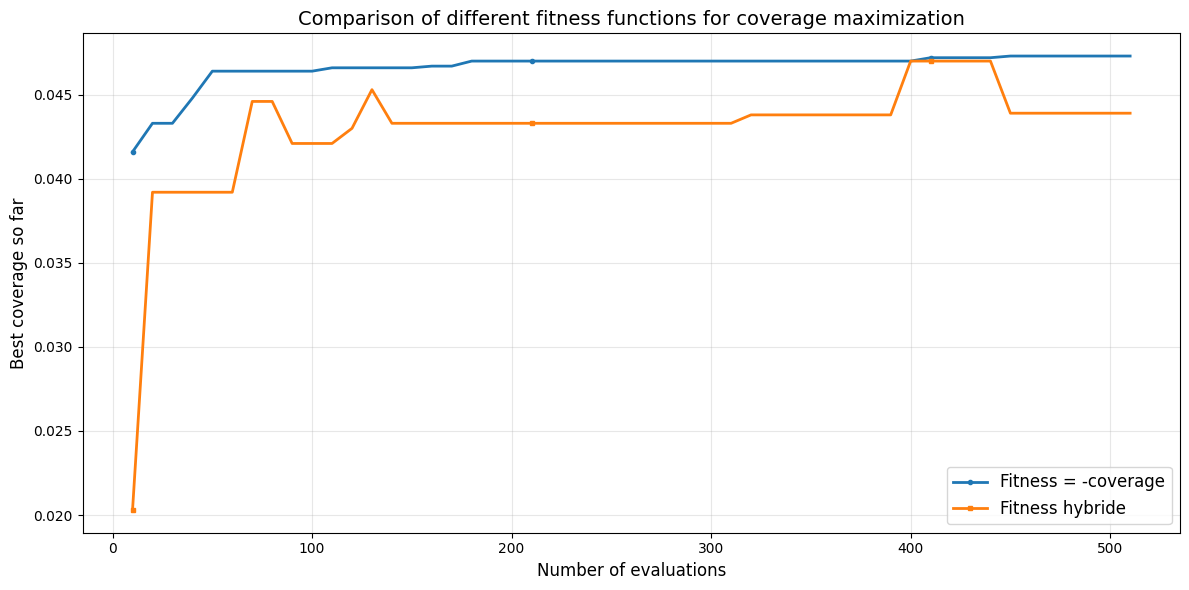


--- Replay du meilleur individu (fitness = -coverage) ---
{'translations': 1.0, 'rotations': np.float64(0.2570700020603623), 'coverage': np.float64(0.0473), 'x_pos_end': 43.78753534473655, 'y_pos_end': 21.738790701235036, 'theta_end': np.float64(1259.5506972060273), 'fitness': np.float64(0.7187256196232512)}


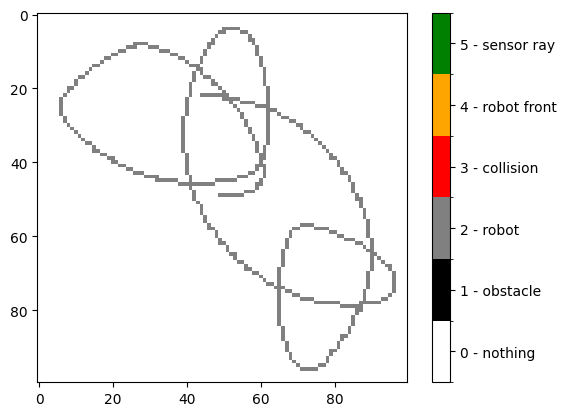


--- Replay du meilleur individu (fitness hybride) ---
{'translations': 0.9481037924151696, 'rotations': np.float64(0.1544108755288004), 'coverage': np.float64(0.0439), 'x_pos_end': 34.706505066231394, 'y_pos_end': 69.35126782537513, 'theta_end': np.float64(773.59848639929), 'fitness': np.float64(0.7013866897449115)}


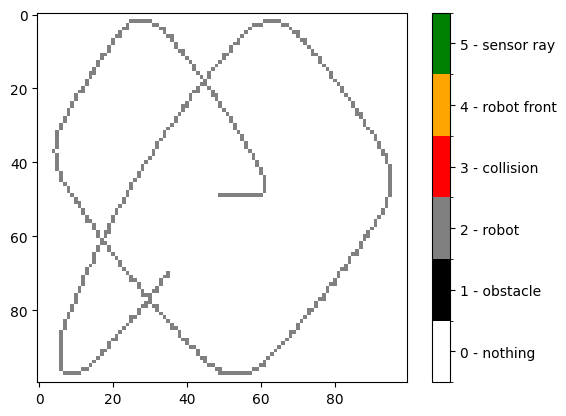


Terminé.


In [36]:
# ==================== Partie 5. Fonctions objectifs et tâches ====================

import matplotlib.pyplot as plt
import numpy as np

arena_size = 100
max_translation_per_step = 1.0
max_rotation_per_step = 10.0
max_iterations = 501              
max_iterations_evolve = 500        

x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

print("\n" + "="*50)
print("Partie 5. Optimisation de la couverture")
print("="*50)

init()
create_arena_walls()
create_wall_1()

def fitness_coverage(params):
    global weights, x_init, y_init, theta_init
    weights = params
    ret = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    return -ret['coverage']

def launch_cmaes_with_coverage(dim, display, ma_func, max_evaluations, record_coverage_func=None):
    x0 = np.random.uniform(-1, 1, dim)
    sigma0 = 0.5
    es = cma.CMAEvolutionStrategy(x0, sigma0)
    es.opts.set({'maxfevals': max_evaluations})
    es.opts.set({
        'verbose': -1 if not display else 1,
        'verb_disp': max(1, max_evaluations // 10),
        'tolfun': 0,
        'tolx': 0,
        'tolconditioncov': 0,
    })
    
    history_evals = []
    history_coverage = []
    
    def callback(es):
        if record_coverage_func is not None:
            best_x = es.best.x
            coverage = record_coverage_func(best_x)
            history_evals.append(es.countevals)
            history_coverage.append(coverage)
    
    es.optimize(ma_func, callback=callback)
    if display:
        es.result_pretty()
    return es.result.fbest, es.result.xbest, history_evals, history_coverage

def get_coverage(params):
    global weights, x_init, y_init, theta_init
    weights = params
    ret = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    return ret['coverage']

print("\n--- Optimisation avec fitness = -coverage ---")
eval = 0
bestFitness_cov, bestParams_cov, evals_cov, coverages_cov = launch_cmaes_with_coverage(
    dim=10,
    display=False,
    ma_func=fitness_coverage,
    max_evaluations=max_iterations_evolve,
    record_coverage_func=get_coverage
)
print(f"Meilleure fitness objective (négative): {bestFitness_cov:.4f}")
print(f"Meilleure couverture réelle: {-bestFitness_cov:.4f}")
print("Meilleurs paramètres (couverture):", bestParams_cov)

def fitness_hybrid(params):
    global weights, x_init, y_init, theta_init
    weights = params
    ret = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
    coverage = ret['coverage']
    movement = ret['translations'] - ret['rotations']
    hybrid = coverage + 0.2 * movement
    return -hybrid

print("\n--- Optimisation avec fitness hybride (coverage + 0.2*movement) ---")
eval = 0
bestFitness_hyb, bestParams_hyb, evals_hyb, coverages_hyb = launch_cmaes_with_coverage(
    dim=10,
    display=False,
    ma_func=fitness_hybrid,
    max_evaluations=max_iterations_evolve,
    record_coverage_func=get_coverage
)
print(f"Meilleure fitness objective (négative): {bestFitness_hyb:.4f}")
actual_hybrid = -bestFitness_hyb
print(f"Meilleure couverture réelle obtenue: {coverages_hyb[-1]:.4f}")
print("Meilleurs paramètres (hybride):", bestParams_hyb)


plt.figure(figsize=(12, 6))
plt.plot(evals_cov, coverages_cov, label='Fitness = -coverage', linewidth=2, marker='o', markersize=3, markevery=20)
plt.plot(evals_hyb, coverages_hyb, label='Fitness hybride', linewidth=2, marker='s', markersize=3, markevery=20)
plt.xlabel('Number of evaluations', fontsize=12)
plt.ylabel('Best coverage so far', fontsize=12)
plt.title('Comparison of different fitness functions for coverage maximization', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Replay du meilleur individu (fitness = -coverage) ---")
weights = bestParams_cov
ret_cov = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
print(ret_cov)
show_trace()

print("\n--- Replay du meilleur individu (fitness hybride) ---")
weights = bestParams_hyb
ret_hyb = simulate_modifier(x_init, y_init, theta_init, my_controller_NN_4sensors)
print(ret_hyb)
show_trace()

print("\nTerminé.")

Q5.1 En optimisant directement la couverture, on obtient une couverture maximale d'environ 4,73 % avec une fitness de 0,718.
Q5.2 La fonction hybride (couverture + 0,2 × mouvement) atteint une couverture légèrement inférieure (4,39 %) mais une fitness plus élevée, indiquant qu'elle privilégie le déplacement au détriment de la couverture.

Les courbes montrent que l'hybride converge plus rapidement mais stagne à une couverture un peu plus faible.

---
---
---

#<font color="orange">Partie 6. Architectures neuronales</font>

Nous allons maintenant modifier la structure de la politique en implémentant des architectures de réseaux de neurones artificiels classiques (mais relativement "légères"). A part la première question, il s'agit d'un exercice difficile à faire *uniquement* si vous avez terminé (et réussi) tout ce qui précède.

En particulier, la dernière question correspond à la mise en place d'une méthodologie rigoureuse de test. Par les temps de calcul qu'elle implique, elle *ne peut pas* être réalisée dans le temps de ce TP. Elle est énoncée ici à titre indicatif (ie. il ne s'agit pas d'un devoir à la maison).

<font color="red">EXERCICES :</font>

- Modifiez la structure de la politique, qui est actuellement une combinaison linéaire des entrées pondérées par des poids. Vous implémenterez un Perceptron simple (fonction d'activation non-linéaire)

- idem avec un perceptron multi-couche (nombre de noeuds à discretion, par exemple 3)

- Comparez ces architectures (y compris celle par défaut). Vous testerez sur les deux fonctions fitness utilisées précédemment: déplacement et couverture. Pour l'instant on se contentera d'un seul run par condition expérimentale (ie. tâche et architecture du réseau).

- idem avec un réseau Elman, c'est à dire avec des connexions récurrentes pour les noeuds de la couche cachée. Chaque noeud de la couche cachée projette sur tous les autres et sur lui-même.

- idem avec un réseau Jordan, c'est à dire avec deux sorties supplémentaires qui projettent sur deux entrées supplémentaires (ie. connexions récurrentes en réinjectant la valeur de certaines sorties produites à *t-1* en valeurs d'entrées à *t*)

- Comparez toutes ces architectures (y compris celle par défaut) avec plusieurs runs indépendant pour chaque conditions expérimentales (type de réseaux, tâches) en variant la position de départ dans un cercle de 4 unités ainsi que l'orientation à chaque évaluation (il sera peut-être nécessaire de ré-évaluer chaque individu pour avoir une bonne approximation de sa performance moyenne). Pour chaque condition expérimentale, vous pouvez vous contentez d'afficher les données brutes du best-ever pour chaque run fait (ou un boxplot si vous avez 11 runs par setup).



========== Tâche : Déplacement ==========

--- Architecture : Linéaire ---
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1049792, Thu Mar 19 17:09:07 2026)
Eval 0: fitness = -0.0233, coverage = 0.0045
Eval 0: fitness = -0.2366, coverage = 0.0066
Eval 0: fitness = 0.6716, coverage = 0.0156
Eval 0: fitness = -0.0000, coverage = 0.0034
Eval 0: fitness = -0.8653, coverage = 0.0009
Eval 0: fitness = -0.0000, coverage = 0.0034
Eval 0: fitness = -0.0000, coverage = 0.0034
Eval 0: fitness = -0.9750, coverage = 0.0001
Eval 0: fitness = -0.3097, coverage = 0.0023
Eval 0: fitness = -0.0000, coverage = 0.0034
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -6.716017706340265e-01 1.0e+00 4.56e-01  4e-01  5e-01 0:00.8
    2     20 -4.012993534022435e-01 1.2e+00 4.53e-01  4e-01  5e-01 0:01.6
    3     30 -6.331580822570351e-01 1.3e+00 4.60e-01  4e-01  5e-01 0:02.4
Eval 30: fitness = 0.0325, coverage = 0.0012
Eval 30: fitness = 0.2622, coverage = 0.002

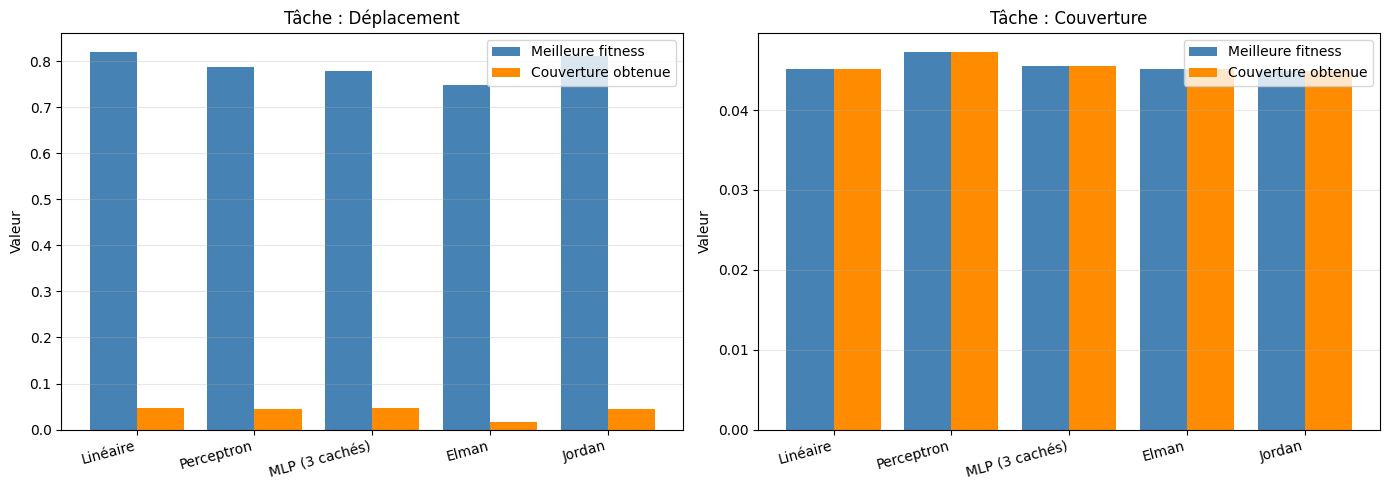

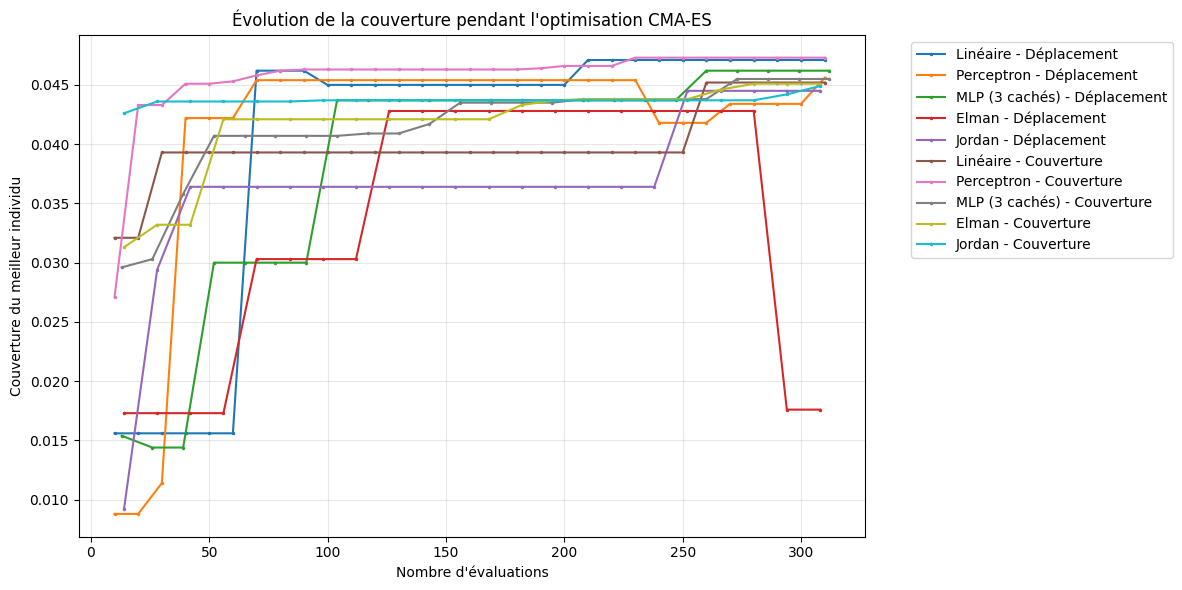


Terminé.


In [37]:
# ==================== Partie 6. Architectures neuronales ====================
# Ce code implémente différentes architectures de réseaux de neurones pour le contrôle du robot
# et les compare sur deux tâches : maximisation du déplacement (movement) et maximisation de la couverture (coverage).
# Les architectures testées : linéaire, perceptron simple, MLP à 1 couche cachée, réseau Elman, réseau Jordan.
# L'optimisation est effectuée avec CMA-ES, et les résultats sont affichés sous forme de graphiques.

import matplotlib.pyplot as plt
import numpy as np
import cma

# -------------------- Paramètres généraux --------------------
arena_size = 100
max_translation_per_step = 1.0
max_rotation_per_step = 10.0
max_iterations = 501               # nombre de pas de simulation par individu
max_iterations_evolve = 300        # nombre d'évaluations pour CMA-ES

# Position et orientation initiales (centre de l'arène, orientation 0°)
x_init = arena_size//2 - particle_box/2
y_init = arena_size//2 - particle_box/2
theta_init = 0

# Construction de l'environnement (avec le mur décalé utilisé précédemment)
init()
create_arena_walls()
create_wall_2(-20)

# -------------------- Définition des contrôleurs --------------------
# Chaque contrôleur utilise la variable globale 'weights' pour ses paramètres.
# Certains nécessitent également des variables d'état globales (pour les réseaux récurrents).

# 1. Contrôleur linéaire (référence)
def controller_linear(sensors):
    global weights
    translation = weights[0]*sensors[-2] + weights[1]*sensors[0] + weights[2]*sensors[2] + weights[3]*sensors[4] + weights[4]
    rotation = weights[5]*sensors[-2] + weights[6]*sensors[0] + weights[7]*sensors[2] + weights[8]*sensors[4] + weights[9]
    return translation, rotation

# 2. Perceptron simple (avec activation non-linéaire tanh)
def controller_perceptron(sensors):
    global weights
    z_trans = weights[0]*sensors[-2] + weights[1]*sensors[0] + weights[2]*sensors[2] + weights[3]*sensors[4] + weights[4]
    z_rot   = weights[5]*sensors[-2] + weights[6]*sensors[0] + weights[7]*sensors[2] + weights[8]*sensors[4] + weights[9]
    translation = np.tanh(z_trans)
    rotation = np.tanh(z_rot)
    return translation, rotation

# 3. Perceptron multicouche (MLP) avec une couche cachée de 3 neurones
# Nombre de poids : 4*3 + 3 (biais caché) + 3*2 + 2 (biais sortie) = 23
def controller_mlp(sensors):
    global weights
    # Extraction des poids
    W1 = np.array(weights[0:12]).reshape(4,3)   # entrée -> caché
    b1 = np.array(weights[12:15])                # biais caché
    W2 = np.array(weights[15:21]).reshape(3,2)   # caché -> sortie
    b2 = np.array(weights[21:23])                 # biais sortie
    # Calcul
    inp = np.array([sensors[-2], sensors[0], sensors[2], sensors[4]])
    h = np.tanh(np.dot(inp, W1) + b1)
    out = np.tanh(np.dot(h, W2) + b2)
    return out[0], out[1]

# 4. Réseau Elman (couche cachée récurrente)
# État caché global (initialisé à zéro)
hidden_state_elman = np.zeros(3)

def controller_elman(sensors):
    global weights, hidden_state_elman
    # Poids : entrée->caché (12), caché->caché (9), biais caché (3), caché->sortie (6), biais sortie (2) -> total 32
    W_in = np.array(weights[0:12]).reshape(4,3)
    W_h = np.array(weights[12:21]).reshape(3,3)
    b_h = np.array(weights[21:24])
    W_out = np.array(weights[24:30]).reshape(3,2)
    b_out = np.array(weights[30:32])
    # Entrée
    inp = np.array([sensors[-2], sensors[0], sensors[2], sensors[4]])
    # Mise à jour de l'état caché
    hidden_state_elman = np.tanh(np.dot(inp, W_in) + np.dot(hidden_state_elman, W_h) + b_h)
    # Sortie
    out = np.tanh(np.dot(hidden_state_elman, W_out) + b_out)
    return out[0], out[1]

# 5. Réseau Jordan (retour des sorties précédentes en entrée)
# Variable globale pour la sortie précédente
prev_output_jordan = np.zeros(2)

def controller_jordan(sensors):
    global weights, prev_output_jordan
    # Poids : entrée (6 dimensions) -> caché (18), biais caché (3), caché->sortie (6), biais sortie (2) -> total 29
    W_in = np.array(weights[0:18]).reshape(6,3)   # 4 capteurs + 2 sorties précédentes
    b_h = np.array(weights[18:21])
    W_out = np.array(weights[21:27]).reshape(3,2)
    b_out = np.array(weights[27:29])
    # Construction de l'entrée (capteurs + sorties précédentes)
    inp = np.array([sensors[-2], sensors[0], sensors[2], sensors[4],
                    prev_output_jordan[0], prev_output_jordan[1]])
    h = np.tanh(np.dot(inp, W_in) + b_h)
    out = np.tanh(np.dot(h, W_out) + b_out)
    # Sauvegarde pour la prochaine étape
    prev_output_jordan = out
    return out[0], out[1]

# -------------------- Fonction d'évaluation individuelle --------------------
def evaluate_individual(controller_func, params, task='movement'):
    """
    Exécute une simulation avec le contrôleur donné et retourne la fitness
    (selon la tâche) ainsi que la couverture finale.
    Les variables d'état des réseaux récurrents sont réinitialisées.
    """
    global weights
    # Réinitialisation des états internes (pour Elman et Jordan)
    global hidden_state_elman, prev_output_jordan
    hidden_state_elman = np.zeros(3)
    prev_output_jordan = np.zeros(2)
    
    weights = params
    ret = simulate_modifier(x_init, y_init, theta_init, controller_func)
    if task == 'movement':
        fitness = ret['translations'] - ret['rotations']   # à maximiser
    elif task == 'coverage':
        fitness = ret['coverage']                           # à maximiser
    else:
        raise ValueError("Tâche inconnue")
    return fitness, ret['coverage']

# -------------------- Lancement de CMA-ES pour une architecture donnée --------------------
def run_cmaes_for_architecture(controller_func, dim, task, max_evals, display=False):
    """
    Optimise les paramètres du contrôleur avec CMA-ES pour la tâche spécifiée.
    Retourne les meilleurs paramètres, la meilleure fitness, la couverture finale,
    ainsi que l'historique des évaluations et des couvertures.
    """
    x0 = np.random.uniform(-1, 1, dim)
    sigma0 = 0.5
    es = cma.CMAEvolutionStrategy(x0, sigma0)
    es.opts.set({'maxfevals': max_evals, 'verbose': -1 if not display else 1})
    # Désactiver les critères d'arrêt prématurés
    es.opts.set({'tolfun': 0, 'tolx': 0, 'tolconditioncov': 0})
    
    history_evals = []      # nombre d'évaluations à chaque enregistrement
    history_coverage = []   # couverture du meilleur individu à ce moment
    
    def objective(params):
        # Fonction objectif pour CMA-ES (minimisation)
        fit, cov = evaluate_individual(controller_func, params.tolist(), task)
        if es.countevals % (max_evals // 10) == 0:
            print(f"Eval {es.countevals}: fitness = {fit:.4f}, coverage = {cov:.4f}")
        return -fit   # on minimise l'opposé de la fitness
    
    def callback(es):
        # Callback appelé après chaque génération pour enregistrer la couverture
        best_params = es.best.x
        fit, cov = evaluate_individual(controller_func, best_params.tolist(), task)
        history_evals.append(es.countevals)
        history_coverage.append(cov)
    
    es.optimize(objective, callback=callback)
    best_params = es.result.xbest
    best_fit = -es.result.fbest   # fitness réelle (maximisée)
    final_cov = history_coverage[-1] if history_coverage else 0
    return best_params, best_fit, final_cov, history_evals, history_coverage

# -------------------- Liste des architectures et des tâches --------------------
architectures = [
    {"name": "Linéaire", "controller": controller_linear, "dim": 10},
    {"name": "Perceptron", "controller": controller_perceptron, "dim": 10},
    {"name": "MLP (3 cachés)", "controller": controller_mlp, "dim": 23},
    {"name": "Elman", "controller": controller_elman, "dim": 32},
    {"name": "Jordan", "controller": controller_jordan, "dim": 29},
]

taches = [
    {"name": "Déplacement", "key": "movement"},
    {"name": "Couverture", "key": "coverage"}
]

# -------------------- Exécution des expériences (un seul run par condition) --------------------
results = {}   # dictionnaire pour stocker les résultats

for tache in taches:
    nom_tache = tache["name"]
    cle_tache = tache["key"]
    print(f"\n========== Tâche : {nom_tache} ==========")
    for arch in architectures:
        nom_arch = arch["name"]
        print(f"\n--- Architecture : {nom_arch} ---")
        best_params, best_fit, final_cov, evals, cov_hist = run_cmaes_for_architecture(
            arch["controller"], arch["dim"], cle_tache, max_iterations_evolve, display=True
        )
        results[(nom_arch, nom_tache)] = {
            "best_fit": best_fit,
            "final_cov": final_cov,
            "params": best_params,
            "cov_history": cov_hist,
            "evals": evals
        }
        print(f"Meilleure fitness : {best_fit:.4f}, Couverture finale : {final_cov:.4f}")

# -------------------- Graphiques comparatifs --------------------
# 1. Diagramme en bâtons : meilleure fitness et couverture atteinte pour chaque architecture et tâche
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
noms_arch = [arch["name"] for arch in architectures]

for idx, tache in enumerate(taches):
    nom_tache = tache["name"]
    fits = [results[(nom_arch, nom_tache)]["best_fit"] for nom_arch in noms_arch]
    covs = [results[(nom_arch, nom_tache)]["final_cov"] for nom_arch in noms_arch]
    
    ax = axes[idx]
    x = np.arange(len(noms_arch))
    ax.bar(x - 0.2, fits, width=0.4, label='Meilleure fitness', color='steelblue')
    ax.bar(x + 0.2, covs, width=0.4, label='Couverture obtenue', color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(noms_arch, rotation=15, ha='right')
    ax.set_title(f'Tâche : {nom_tache}')
    ax.set_ylabel('Valeur')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Évolution de la couverture au cours de l'optimisation (pour chaque architecture)
plt.figure(figsize=(12, 6))
for tache in taches:
    nom_tache = tache["name"]
    for arch in architectures:
        nom_arch = arch["name"]
        cov_hist = results[(nom_arch, nom_tache)]["cov_history"]
        evals = results[(nom_arch, nom_tache)]["evals"]
        if cov_hist:
            plt.plot(evals, cov_hist, label=f'{nom_arch} - {nom_tache}', marker='.', linestyle='-', markersize=3)
plt.xlabel('Nombre d\'évaluations')
plt.ylabel('Couverture du meilleur individu')
plt.title('Évolution de la couverture pendant l\'optimisation CMA-ES')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTerminé.")

---
---
---

#<font color="orange">Fin du sujet.</font>

---
---
---
